# WH - Limit Plots

This notebook plots:

- 1D Brazil limit plots which show the observed and expected xsection limits as a function of $m_s$ for a given $m_{\phi}$, T and decay mode.  
- 2D limit plot of the observed excluded mu value as a function of $m_{\phi}$ (x-axis) and T (y-axis). 
- Summary plots: showing the $\mu=1$ exclusion limit for every value of $m_s$ and decay mode.

Using functions in `plot_utils.py`.

Use the Outline to navigate to the desired section.

In [1]:
%config InlineBackend.figure_format = 'retina'
import os
import matplotlib.pyplot as plt
from matplotlib import ticker
import numpy as np
import plot_utils as utils

plt.style.use('physics.mplstyle')

import mplhep as hep
hep.style.use("CMS")

In [2]:
# parameters
itag = '../cards/WH_2_6_toys/'

outDir = '/home/submit/{}/public_html/WH/limits/'.format(os.environ['USER'])
outDirAN = '/home/submit/{}/SUEP/AN-23-183/images/'.format(os.environ['USER'])
# outDirPaper = '/home/submit/{}/SUEP/EXO-23-002/'.format(os.environ['USER'])
# outDirSupp = '/home/submit/{}/SUEP/EXO-23-002/supplementary/'.format(os.environ['USER'])
outDirPAS = '/home/submit/lavezzo/SUEP/PAS/EXO-24-030/images/'

saveToAN = False
saveToPaper = False
saveToPAS = False

# if not os.path.isdir(outDir): os.mkdir(outDir)

## 1D Limits: $T_D/m_{\phi}$ scan

In [3]:
import numpy as np
zh = np.loadtxt("SRCR_generic_limAsy.txt", delimiter=":")
norm = 0.909
obs = zh[:,-1]
mPhi = zh[:,1]
T = zh[:,2]
s2m = zh[:, 3]
s1m = zh[:, 4]
exp = zh[:, 5]
s1p = zh[:, 6]
s2p = zh[:, 7]

FileNotFoundError: SRCR_generic_limAsy.txt not found.

not found: 'limit' (with any cycle number)

    Available keys: (none!)

in file ../cards/WH_3_9/higgsCombineSUEP_mS125.000_mPhi3.000_T12.000_modegeneric.AsymptoticLimits.mH125.root
File doesn't exist ../cards/WH_3_9/higgsCombineSUEP_mS125.000_mPhi3.000_T12.000_modegeneric.AsymptoticLimits.mH125.root
not found: 'limit' (with any cycle number)

    Available keys: (none!)

in file ../cards/WH_3_9/higgsCombineSUEP_mS125.000_mPhi3.000_T12.000_modegeneric.AsymptoticLimits.mH125.root
File doesn't exist ../cards/WH_3_9/higgsCombineSUEP_mS125.000_mPhi3.000_T12.000_modegeneric.AsymptoticLimits.mH125.root
not found: 'limit' (with any cycle number)

    Available keys: (none!)

in file ../cards/WH_3_9/higgsCombineSUEP_mS125.000_mPhi3.000_T12.000_modegeneric.AsymptoticLimits.mH125.root
File doesn't exist ../cards/WH_3_9/higgsCombineSUEP_mS125.000_mPhi3.000_T12.000_modegeneric.AsymptoticLimits.mH125.root
not found: 'limit' (with any cycle number)

    Available keys: (none!)

in file ../cards/WH_3

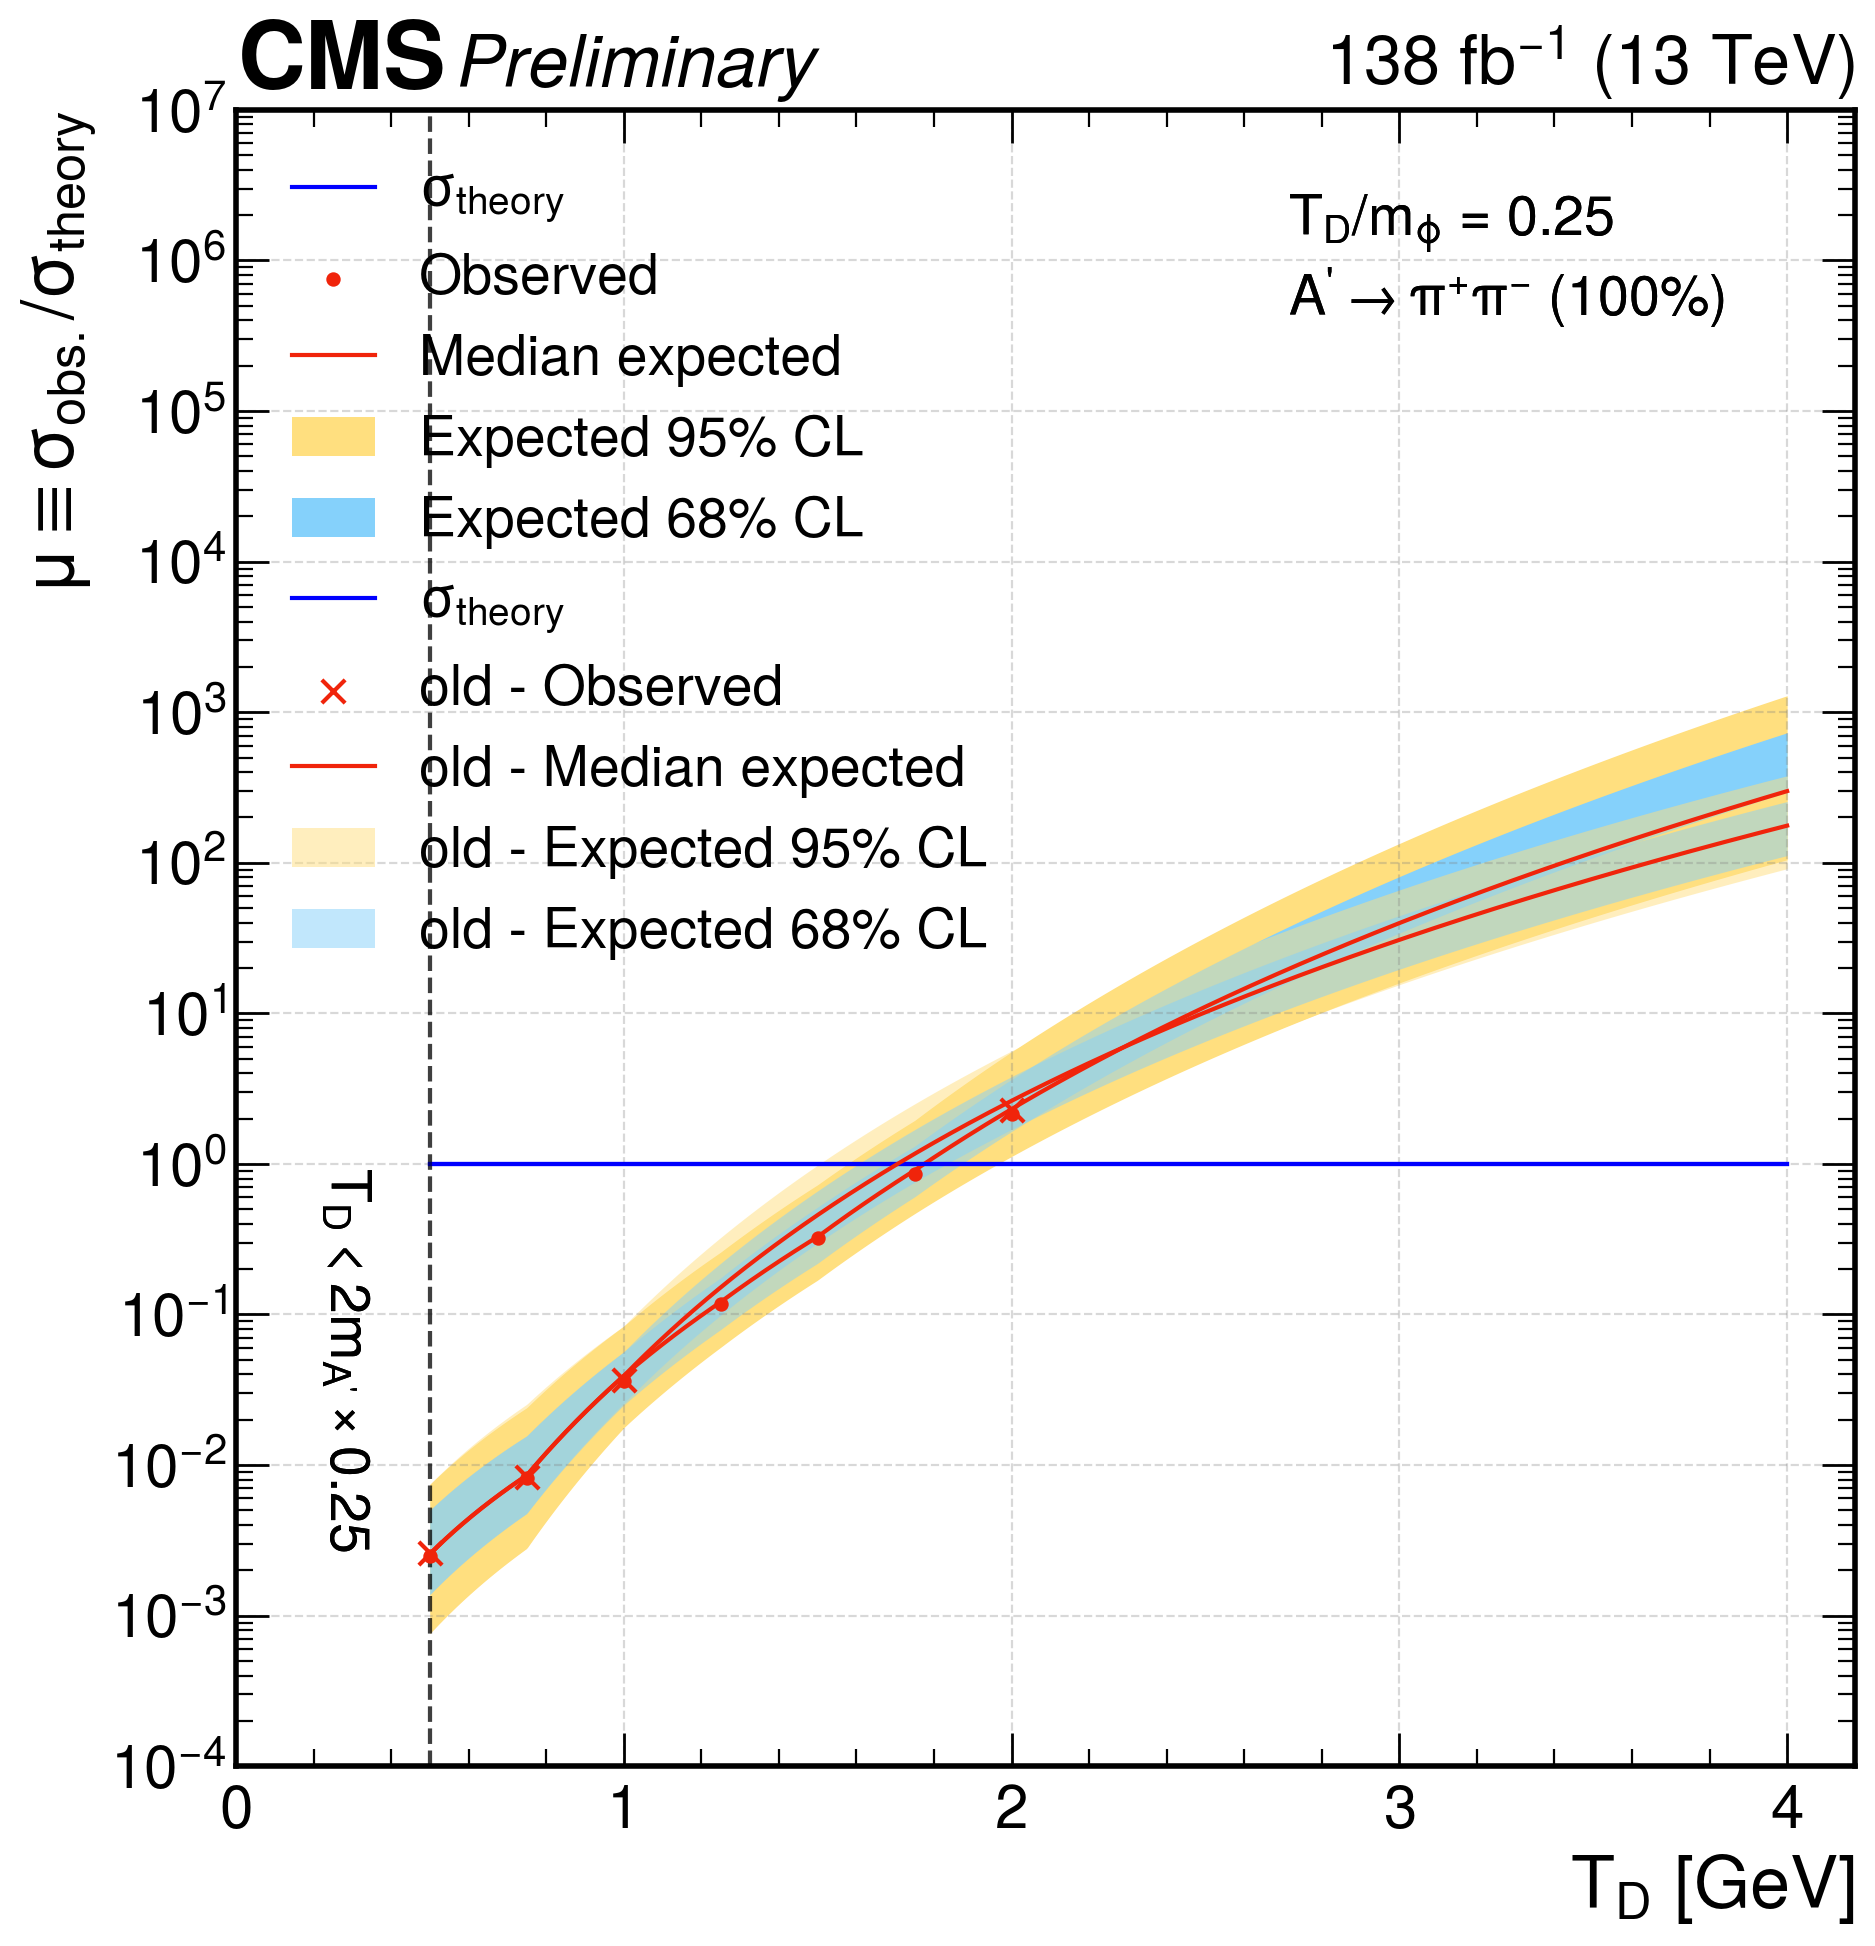

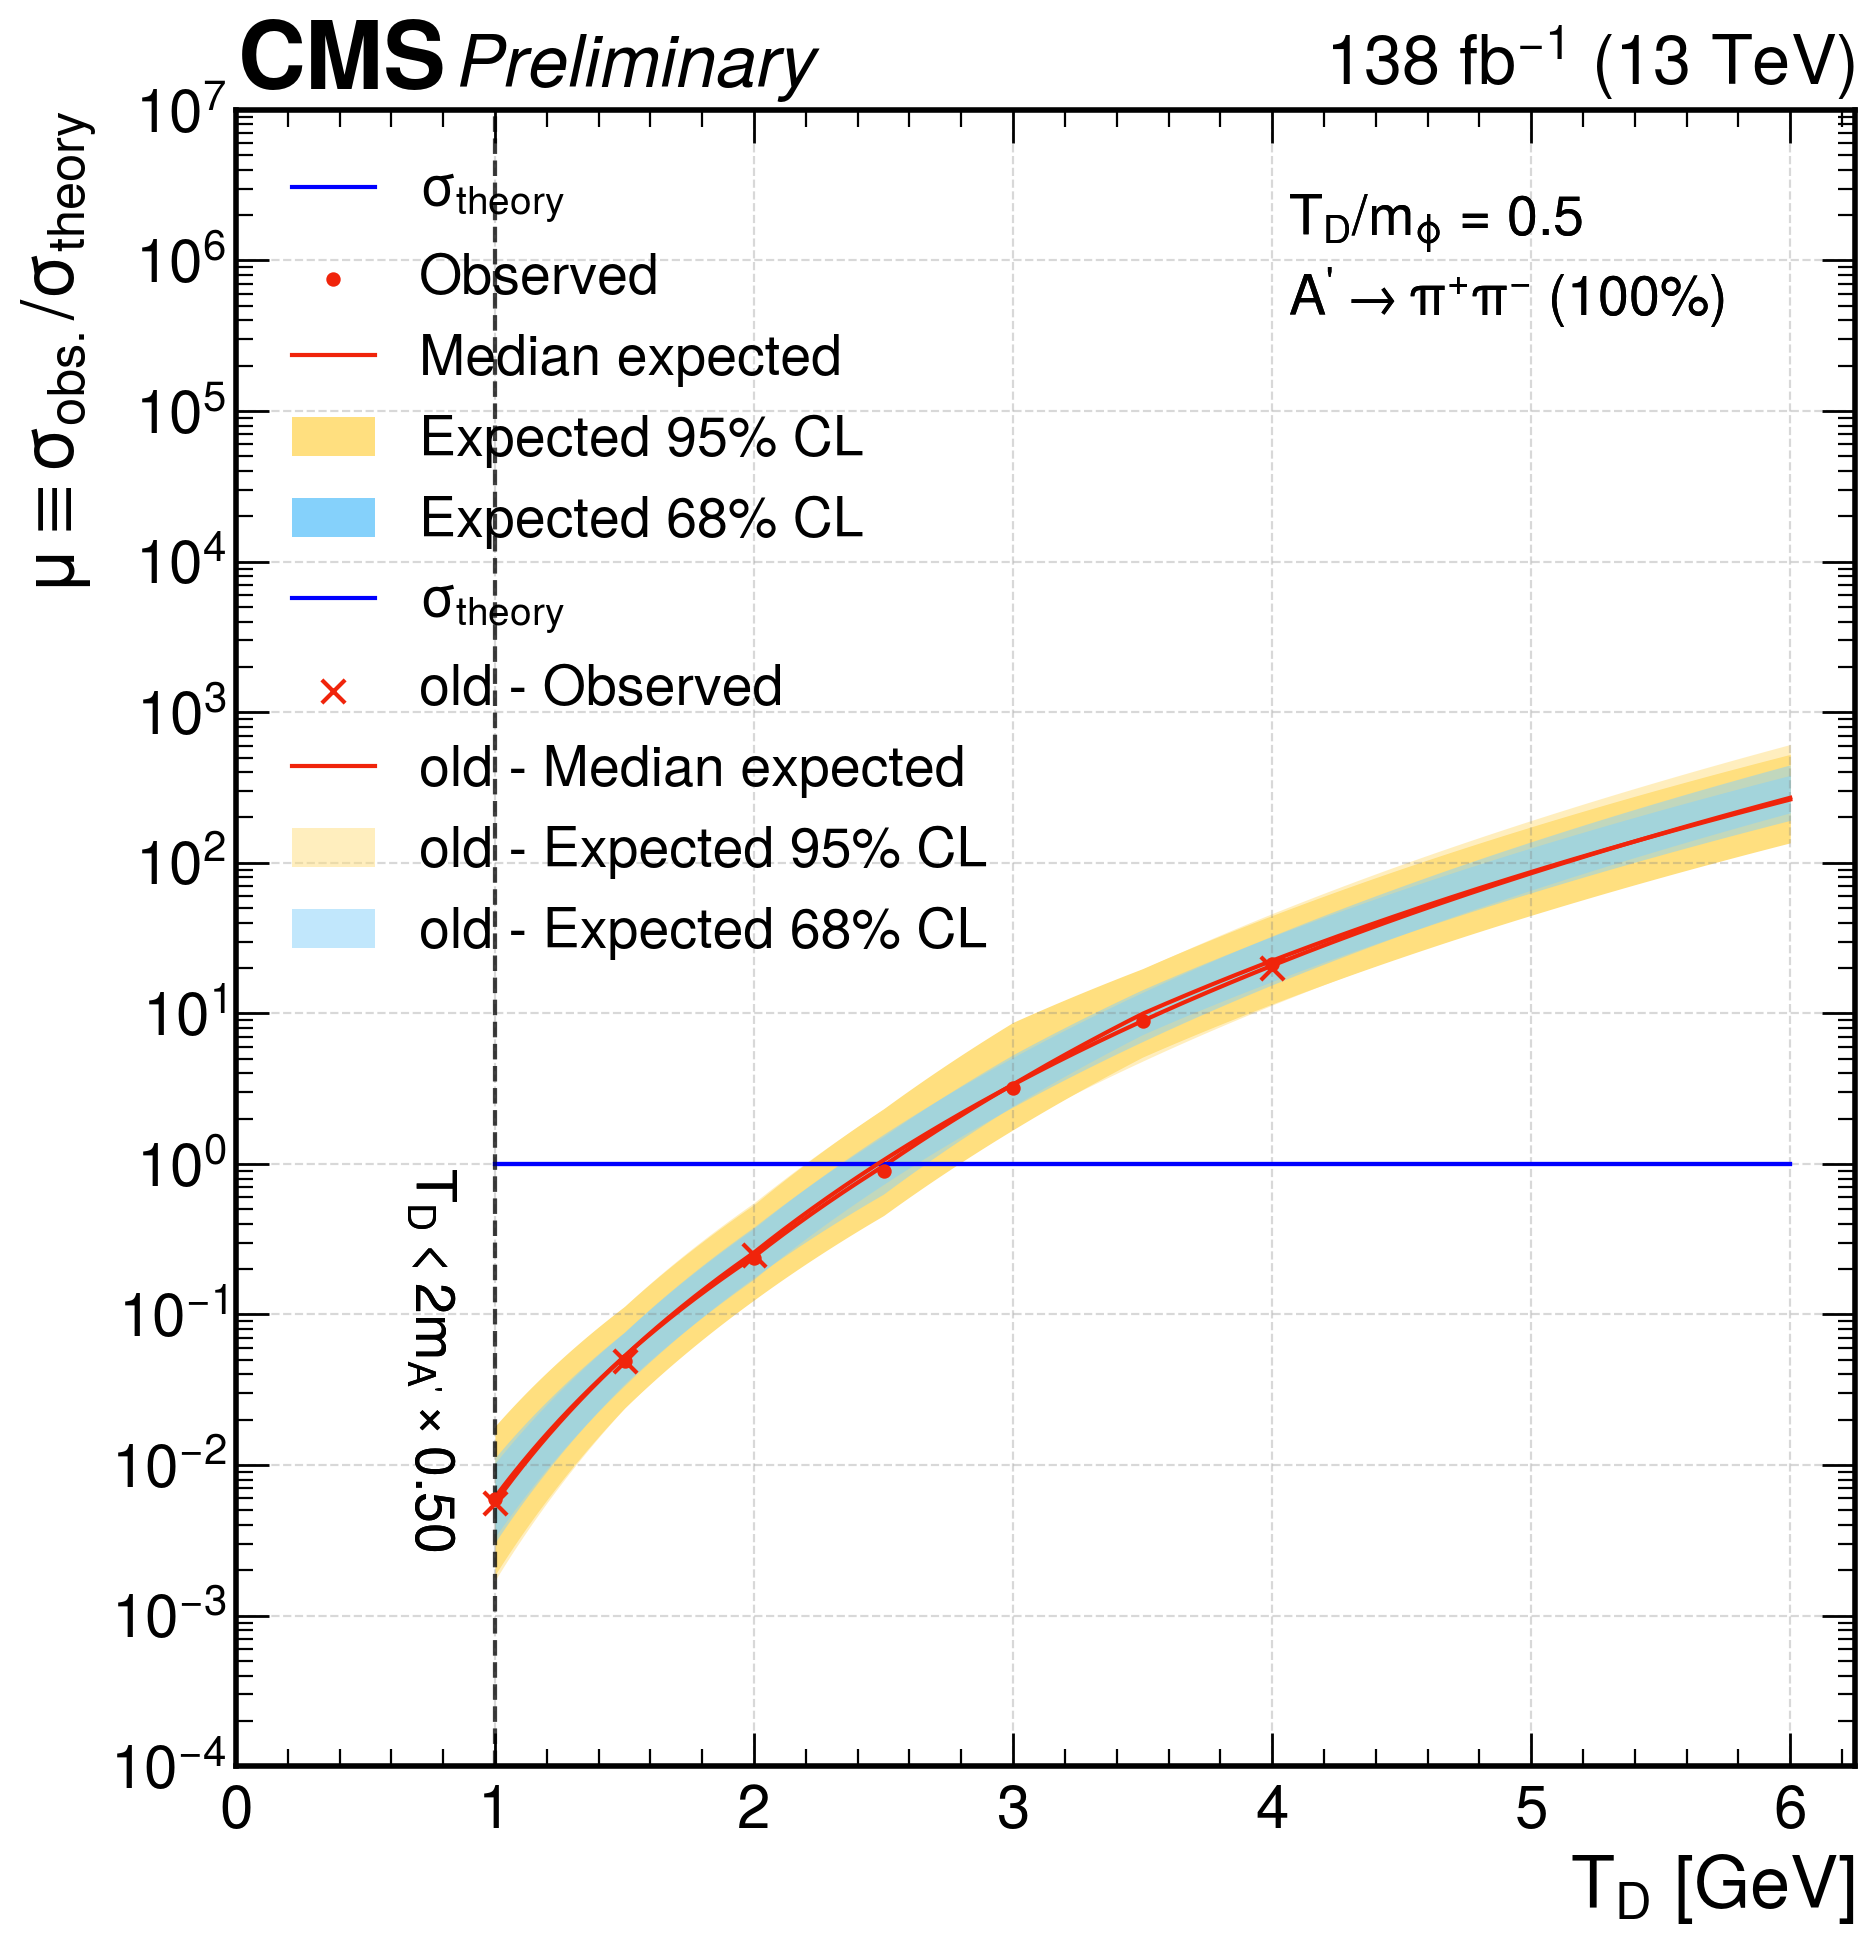

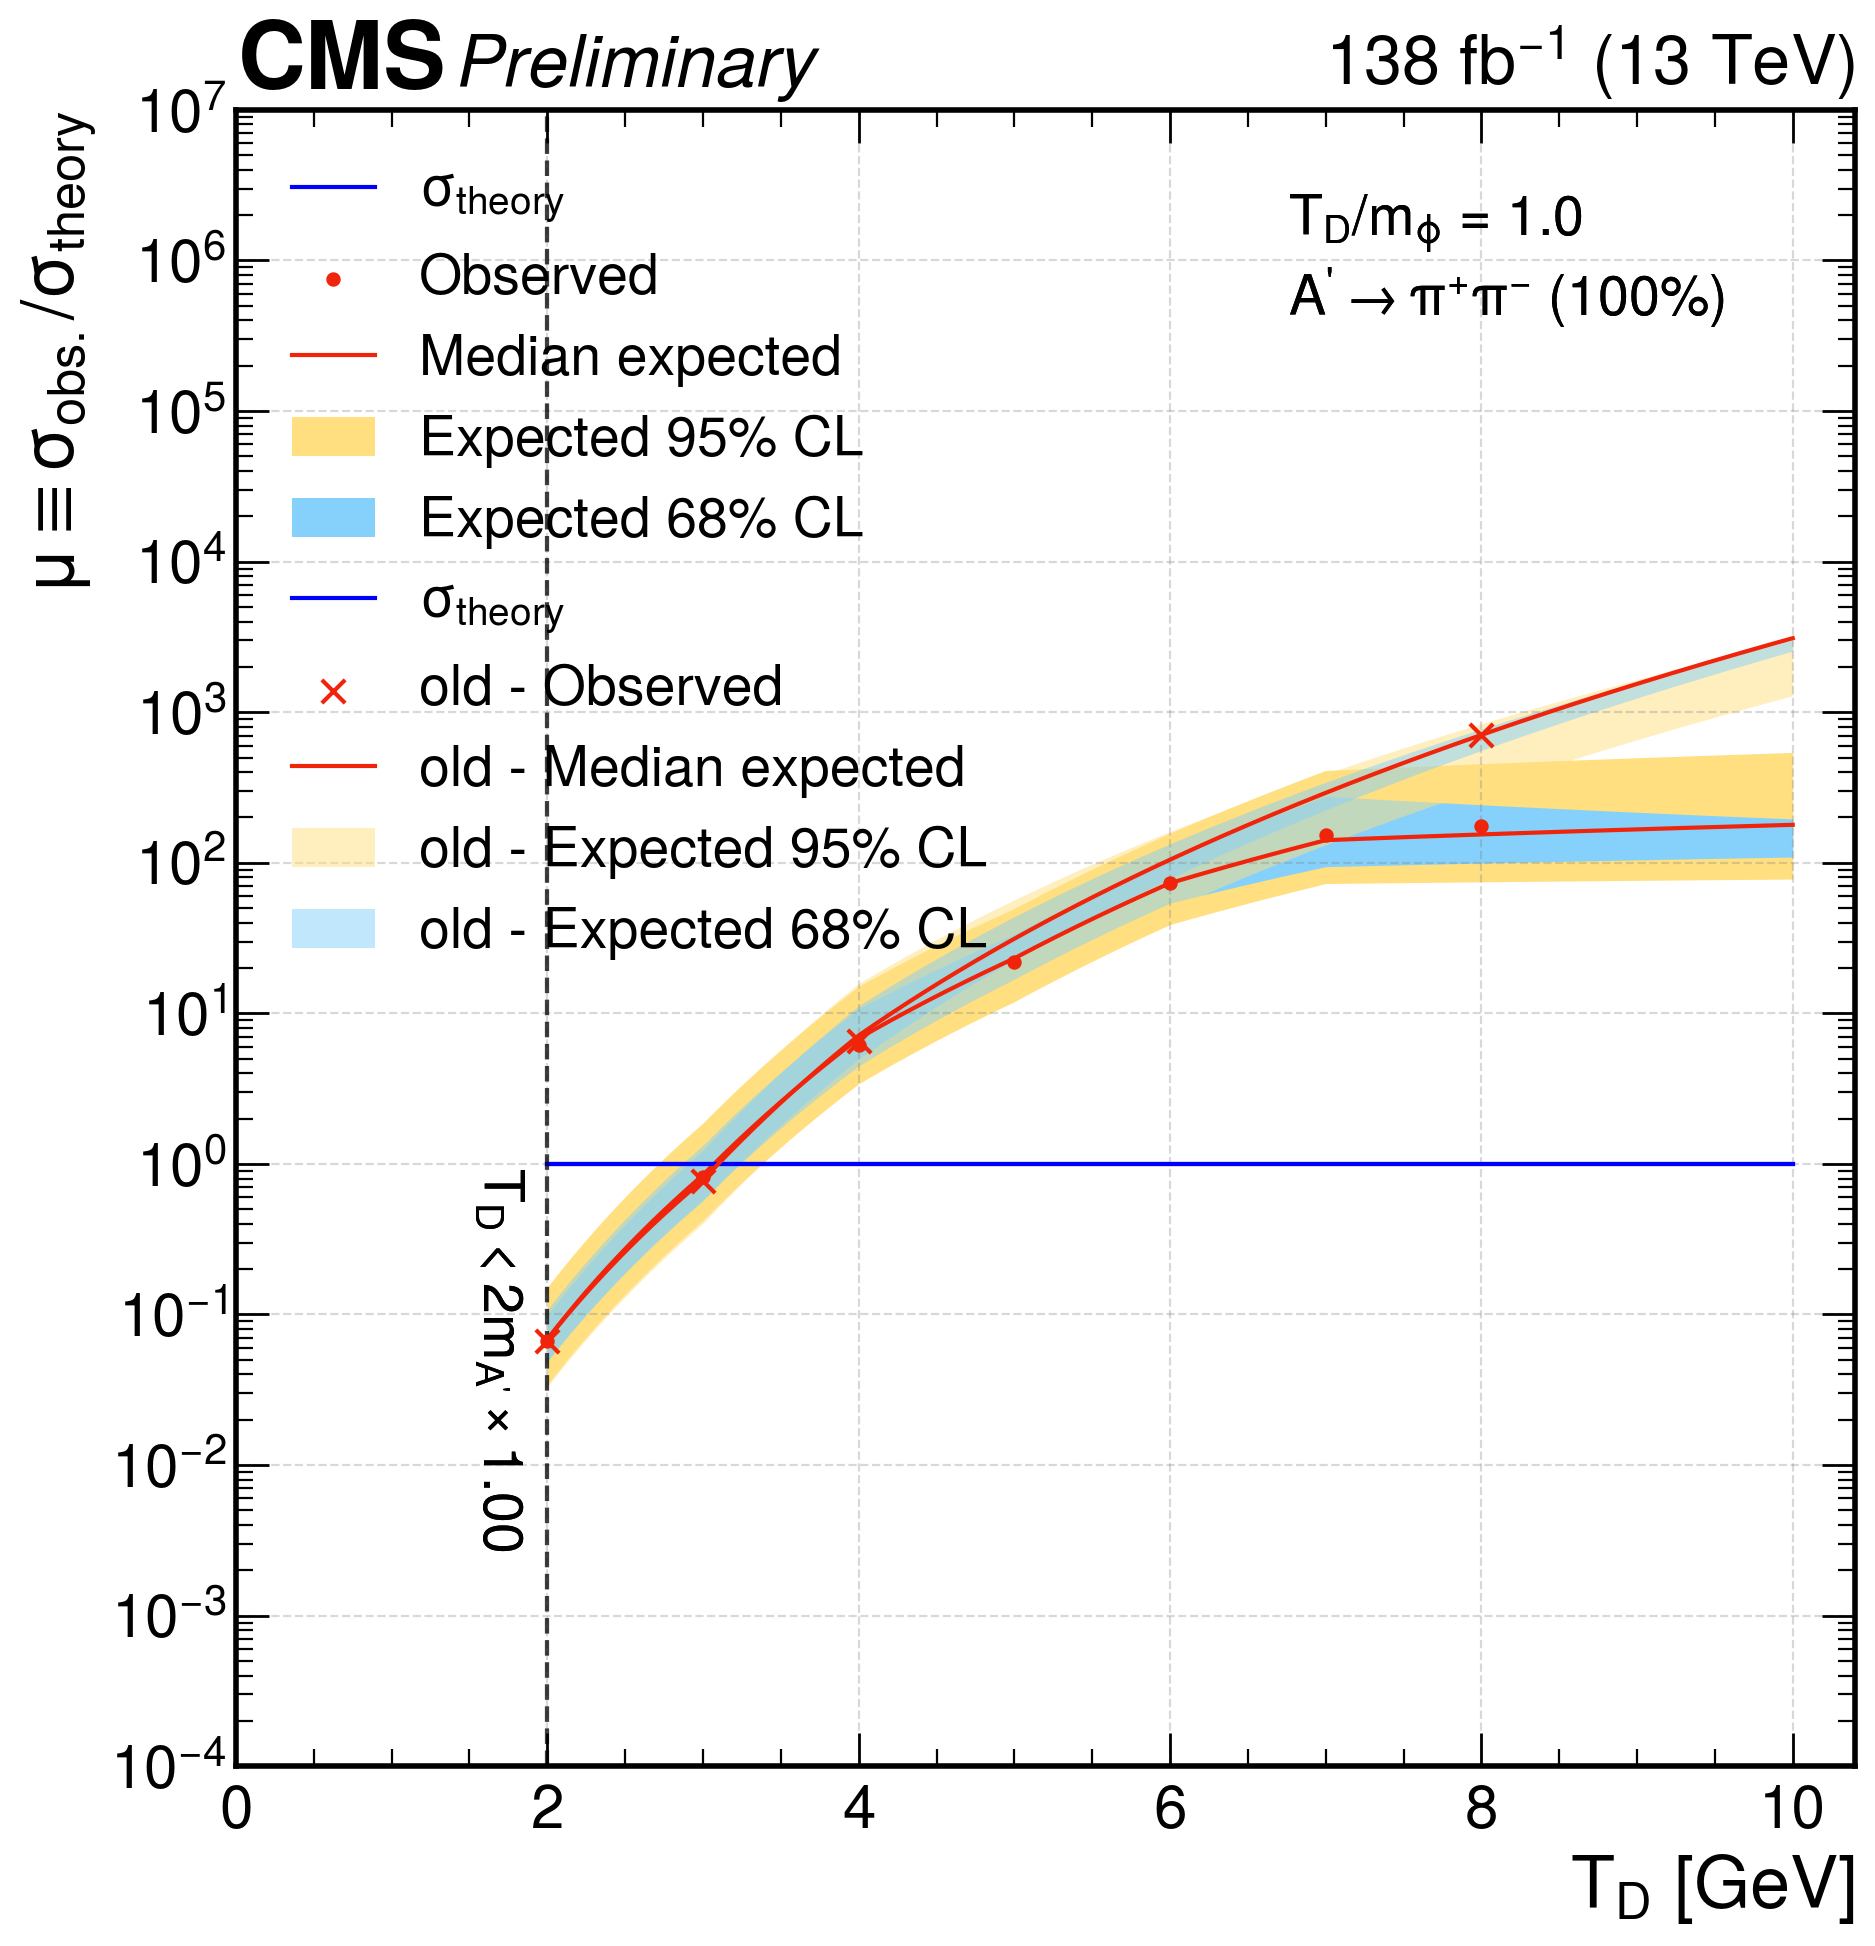

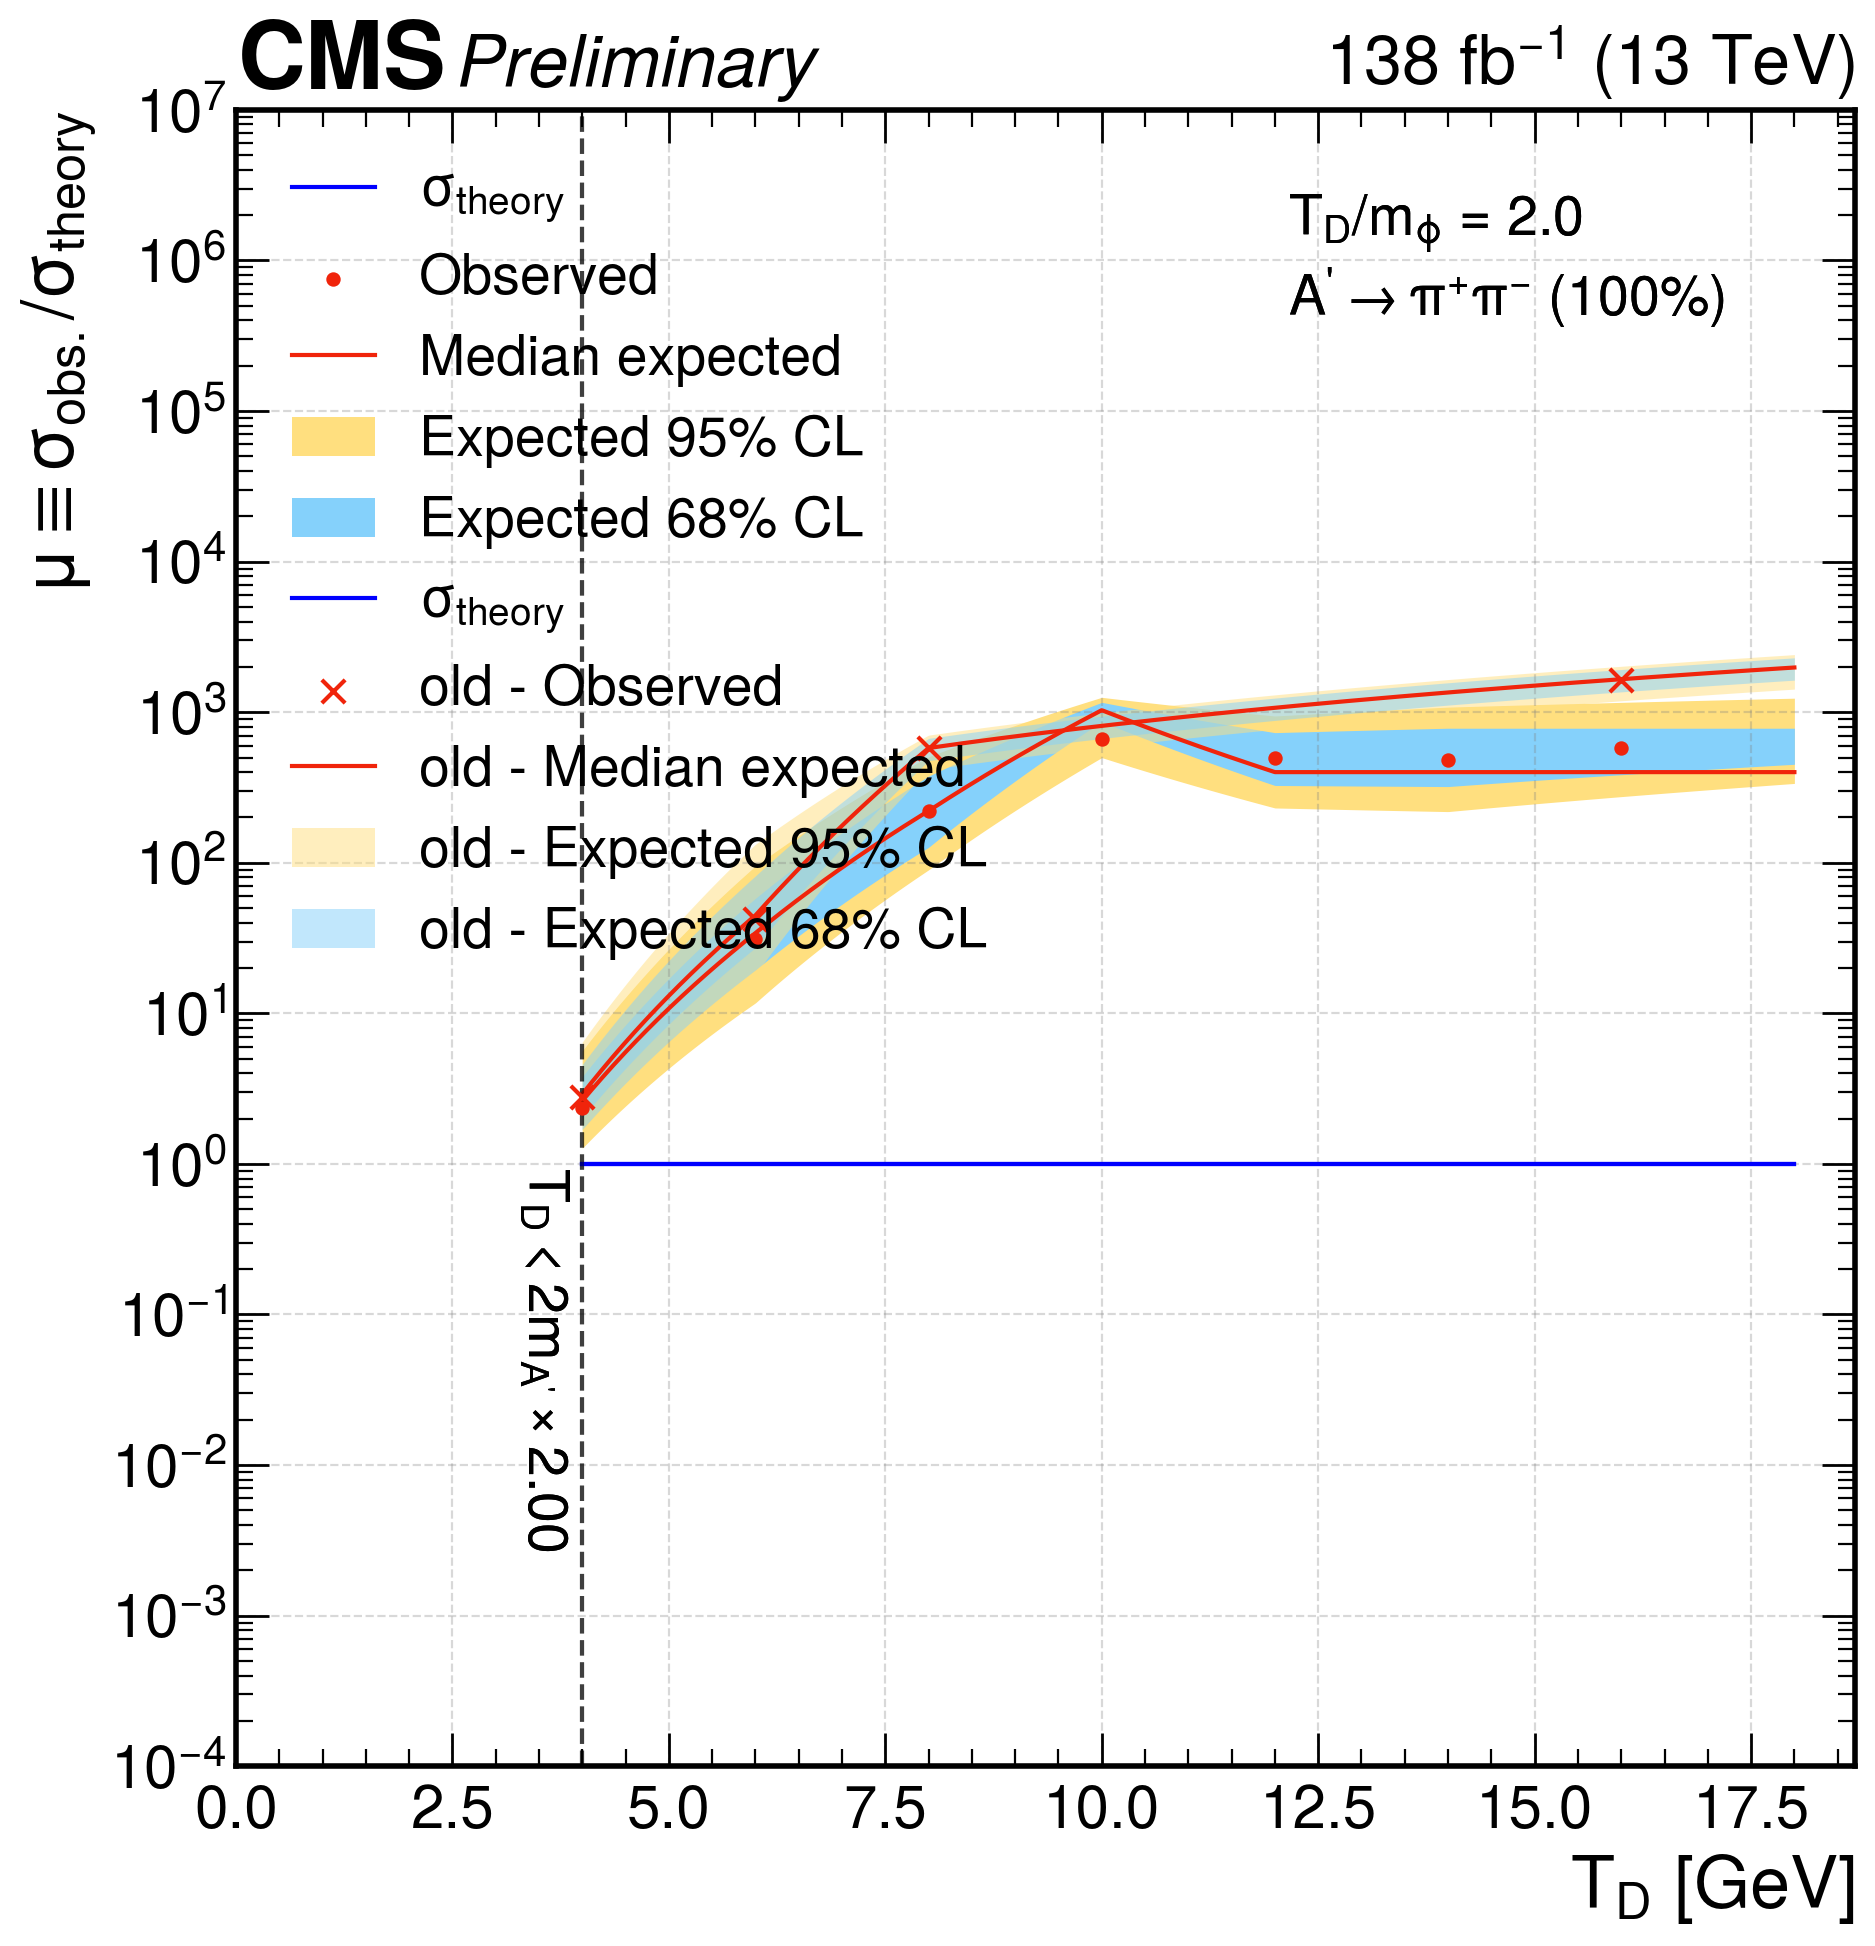

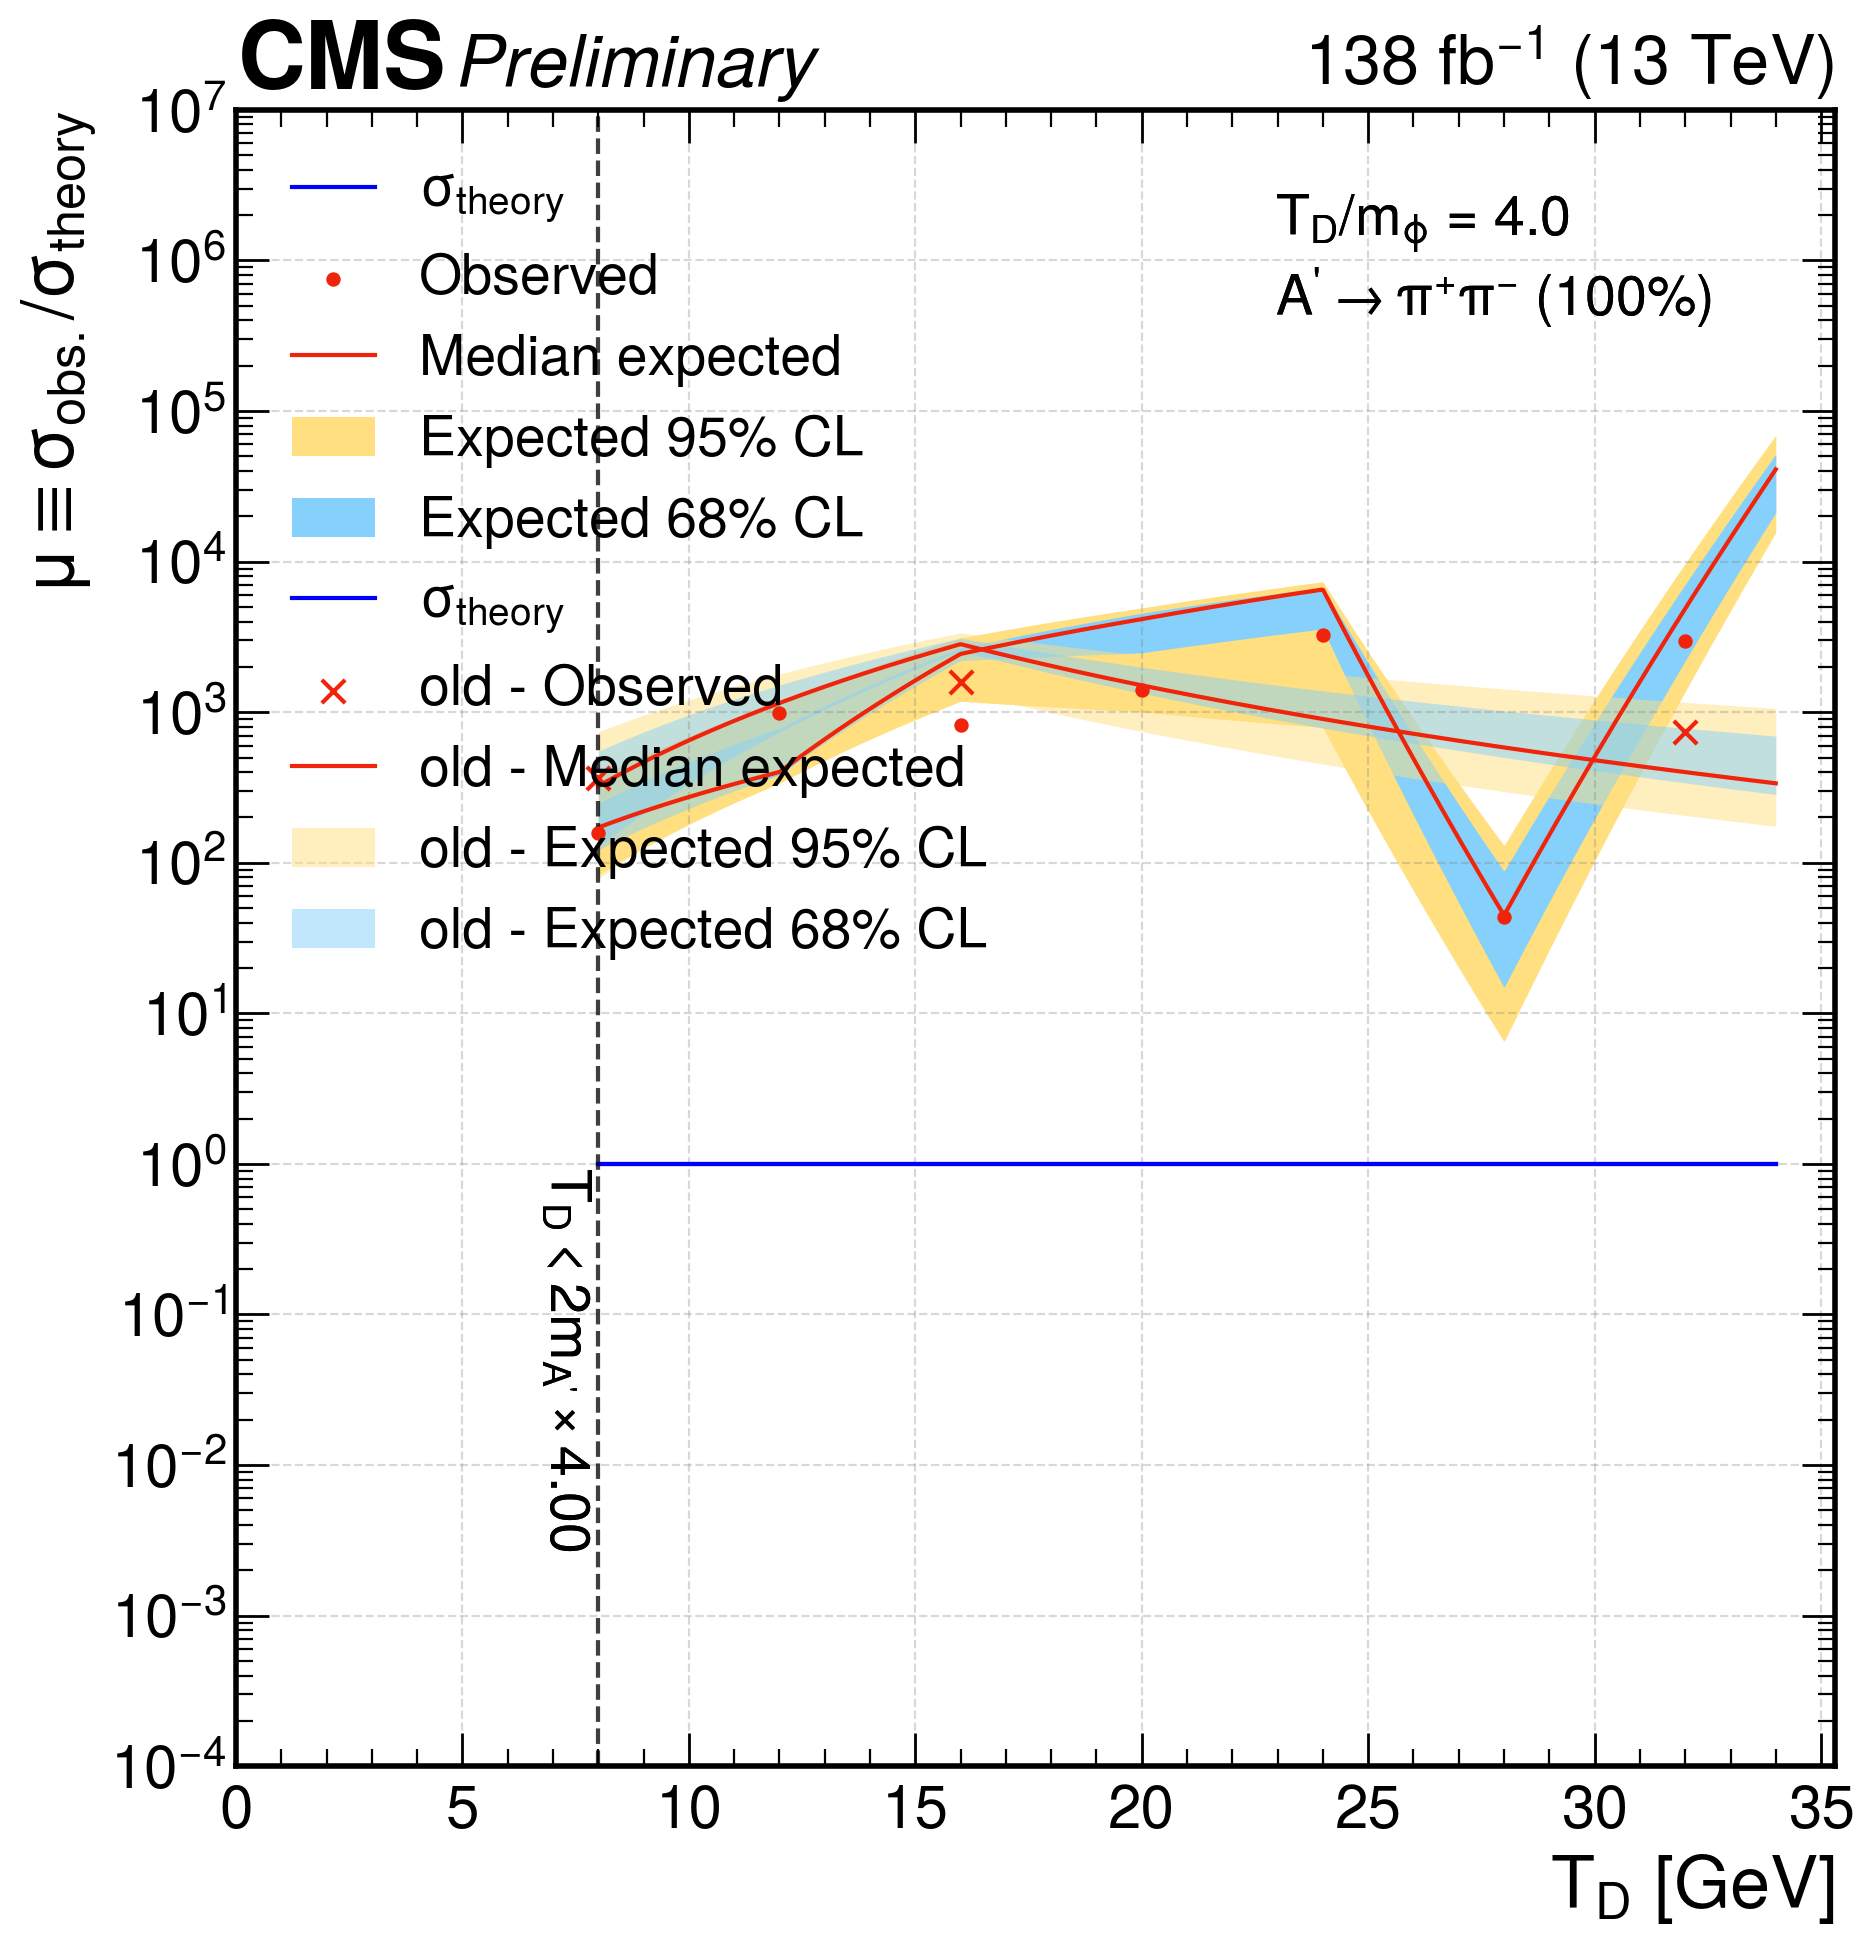

In [4]:
decay_modes = [
    #'leptonic', 
    #'hadronic',
    'generic'
]
mphi_by_t = [
    0.25,
    0.5,
    1.0,
    2.0,
    4.0
]
show_zh = False

for i in mphi_by_t:
    for decay_mode in decay_modes:

        fig = utils.plot_mphi_by_T_limits(temp_by_mphi=i, ms=125, decay=decay_mode, path='../cards/private_signals/', obs_marker='.', method='AsymptoticLimits', analysis='wh', mu_limit=True)
        hep.cms.label(data=True, llabel='Preliminary', lumi=utils.lumis['combined'], ax=fig.get_axes()[0])

        ax = utils.plot_mphi_by_T_limits(temp_by_mphi=i, ms=125, decay=decay_mode, path='../cards/WH_3_9/', obs_marker='x', method='AsymptoticLimits', analysis='wh-old', mu_limit=True, ax=fig.get_axes()[0], exp_alpha=0.5, legend_label='old - ')

        # code for adding the ZH limits to this plot
        if show_zh:
            mask = (T/mPhi == i) & (T < 10) & ((T != 0.5) & (mPhi != 0.5) & (T != 1.0) & (mPhi != 1.0))

            xvar = np.linspace(min(T[mask]), max(T[mask])+2, 1000)
            exp_limit = utils.log_interp1d(T[mask], exp[mask]) 
            s1p_limit = utils.log_interp1d(T[mask], s1p[mask])
            s1m_limit = utils.log_interp1d(T[mask], s1m[mask])
            s2p_limit = utils.log_interp1d(T[mask], s2p[mask])
            s2m_limit = utils.log_interp1d(T[mask], s2m[mask])

            ax = fig.get_axes()[0]
            ax.plot(xvar, exp_limit(xvar), ls="--", ms=12, color='cyan', label="ZH Median expected")
            ax.fill_between(xvar, s2m_limit(xvar), s2p_limit(xvar), color="blue", alpha=0.3, lw=0, label="ZH Expected 95% CL")
            ax.fill_between(xvar, s1m_limit(xvar), s1p_limit(xvar), color="darkblue", alpha=0.3, lw=0, label="ZH Expected 68% CL")
            ax.scatter(T[mask], obs[mask], marker='*', s=70, color='cyan', label="ZH Observed") 

        if saveToAN:
            fig.savefig(outDirAN + fig.get_label() + '.pdf', bbox_inches='tight')

## 2D Limits: $m_{\phi}$, T scan

In [54]:
import pandas as pd
import matplotlib.tri as tri
import math

def plot_mPhi_temp_limits(
        ms:int,
        decay:str,
        path:str,
        tricontour:str ='log', 
        calculateWithoutPlotting:bool=False,
        returnContour:bool=False,
        cmsLabel:bool=True,
        showPoints:bool=False,
        method:str='AsymptoticLimits',
        showTheoryLines:bool=False,
        showObserved:bool=True,
        autoRange:bool=True,
        analysis:str='ggf-offline',
        muLimit:bool=False,
        T_by_mPhi:bool=False
    ): 
    """
    Make 2D limit plot on the cross section for some choice of mS and decay, scanning over T and mPhi.
    Inputs:
        mS: scalar mass
        decay: decay channel
        path: path to the directory containing the higgsCombined files
        tricontour: 'log' or 'lin' to interpolate through log(mu) or mu
        calculateWithoutPlotting: if True, the function returns the interpolated limits without plotting them
        returnContour: if True, the function returns the contour object and quits
        cmsLabel: if True, the CMS label is added to the plot
        showPoints: shows were the actual samples are
        method: 'AsymptoticLimits' or 'HybridNew'
        showTheoryLines: if True, the theory line is shown
        autoRange: if True, the range of the plot is automatically set
        analysis: 'ggf-offline', 'ggf-scouting', 'ggf-tth', 'wh'
        muLimit: if True, the limit is on mu, not on the cross section
    Outputs:
        fig: figure object
    """
    import seaborn as sns

    if tricontour not in ['log','lin']: #tricontour decides whether we interpolate through mu ('lin') or log(mu) ('log')
        raise Exception("tricontour should be 'log' or 'lin'")

    scan_limits = utils.get_scan_limits(path=path, ms=ms, decay=decay, method=method, analysis=analysis, return_xsec=not muLimit)
        
    # Reorganize data
    limit_xsec = np.stack([s[1] for s in scan_limits]) 
    limit_mphi = np.array([s[0][1] for s in scan_limits]) 
    limit_temp =  np.array([s[0][2] for s in scan_limits])
    if T_by_mPhi:
        limit_temp = np.log2(limit_temp / limit_mphi)
    xsec_theory = scan_limits[0][0][-1]

    if tricontour == 'log':
        limit_xsec[:,1,:]= np.log10(limit_xsec[:,1,:]) # Convert mu to logarithm of mu 
    
    data = pd.DataFrame(
        {
            "mH"  : np.array(limit_temp),
            "ma"  : np.array(limit_mphi),
            "m2s" : np.array(limit_xsec)[:,1,0],
            "m1s" : np.array(limit_xsec)[:,1,1],
            "exp" : np.array(limit_xsec)[:,1,2],
            "p1s" : np.array(limit_xsec)[:,1,3],
            "p2s" : np.array(limit_xsec)[:,1,4],
            "obs" : np.array(limit_xsec)[:,1,5],
        }
    )
    
    # Plot figure and obtain mu=1 (log(mu)=0) lines
    fig = plt.figure(figsize=(12,9))
    ax = fig.subplots()

    cmap = sns.color_palette("flare_r", as_cmap=True)    
    if tricontour == 'log':
        levels = np.linspace(min(data['obs']), max(data['obs']))
        triang = tri.Triangulation(limit_mphi, limit_temp)
        contour = ax.tricontourf(triang, data['obs'], levels=levels, cmap=cmap)
        cb = fig.colorbar(contour, pad=0.01) 
        if muLimit:
            cb.ax.set_ylabel(r'$95\%$ CL obs. upper limit on $\mu$', loc='top', rotation=90, fontsize=25)
        else:    
            cb.ax.set_ylabel(r'$95\%$ CL obs. upper limit on $\sigma$ (pb)', loc='top', rotation=90, fontsize=25)
        ticks = (np.array(range(math.ceil(min(data['obs'])), math.floor(max(data['obs'])) + 1)))
        cb.set_ticks(ticks)
        labels = ['$10^{'+str(i)+'}$' for i in ticks]
        cb.set_ticklabels(labels)      

    if tricontour == 'lin':
        levels = np.logspace(np.log10(min(data['obs'])),np.log10(max(data['obs'])))
        contour = ax.tricontourf(limit_mphi, limit_temp, data['obs'], levels =levels,locator=ticker.LogLocator(), cmap=cmap)
        formatter = ticker.LogFormatter(base=10, labelOnlyBase=True) 
        cb = fig.colorbar(contour, pad=0.01, format=formatter, label=r'$\mu$')
        cb.ax.set_ylabel(r'$95\%$ CL obs. upper limit on $\sigma$ (pb)', loc='top', rotation=90, fontsize=25)
        cb.locator = ticker.LogLocator(base=10.0, subs=[1.0], numdecs=7, numticks=45)
        cb.update_ticks()

    if returnContour:
        plt.close()
        return triang, data['obs']
     
    # put a limit on limit_xsec == xsec_theory
    if tricontour == 'log': level=np.log10(xsec_theory)
    if tricontour == 'lin': level=xsec_theory
        
    # NOTE: suppressing +- 2 sigma (p0 and p4)
    p0 = ax.tricontour(limit_mphi, limit_temp, limit_xsec[:,1,0],levels=[level], colors="k", alpha=0) # -2 sigma expected
    p1 = ax.tricontour(limit_mphi, limit_temp, limit_xsec[:,1,1],levels=[level],   colors="k", alpha=0) # -1 sigma expected
    p2 = ax.tricontour(limit_mphi, limit_temp, limit_xsec[:,1,2],levels=[level],   colors="k", alpha=0) # median expected
    p3 = ax.tricontour(limit_mphi, limit_temp, limit_xsec[:,1,3],levels=[level],  colors="k", alpha=0) # +1 sigma expected
    p4 = ax.tricontour(limit_mphi, limit_temp, limit_xsec[:,1,4],levels=[level],  colors="k", alpha=0) # +2 sigma expected
    p5 = ax.tricontour(limit_mphi, limit_temp, limit_xsec[:,1,5],levels=[level],  colors="k", alpha=0) # observed
    
    if showPoints:
        ax.scatter(limit_mphi, limit_temp, marker='o', color='black', label='Signal point', s=10)
                
    line0 = np.array(p0.collections[0].get_paths()[0].vertices)
    line1 = np.array(p1.collections[0].get_paths()[0].vertices)
    line2 = np.array(p2.collections[0].get_paths()[0].vertices)
    line3 = np.array(p3.collections[0].get_paths()[0].vertices)
    line4 = np.array(p4.collections[0].get_paths()[0].vertices)
    line5 = np.array(p5.collections[0].get_paths()[0].vertices)

    if calculateWithoutPlotting:
        plt.close()
        return line1, line2, line3, line5

    xvar = np.linspace(utils.mA[decay]*2, 8, 1000)

    line0_interpolator = utils.interp1d(line0[:,0], line0[:,1])
    line4_interpolator = utils.interp1d(line4[:,0], line4[:,1])
    line1_interpolator = utils.interp1d(line1[:,0], line1[:,1])
    line3_interpolator = utils.interp1d(line3[:,0], line3[:,1])
    line5_interpolator = utils.interp1d(line5[:,0], line5[:,1])
    line2_interpolator = utils.interp1d(line2[:,0], line2[:,1])

    line0_interp = line0_interpolator(xvar)
    line4_interp = line4_interpolator(xvar)
    line1_interp = line1_interpolator(xvar)
    line3_interp = line3_interpolator(xvar)
    line5_interp = line5_interpolator(xvar)
    line2_interp = line2_interpolator(xvar)
    

    line0_interp[line0_interp < -2] = -2
    line4_interp[line4_interp < -2] = -2
    line1_interp[line1_interp < -2] = -2
    line3_interp[line3_interp < -2] = -2
    line5_interp[line5_interp < -2] = np.nan
    line2_interp[line2_interp < -2] = np.nan
    
    # smoooth
    # x0,y0 = utils.interp_limit(line0, 4)
    # x1,y1 = utils.interp_limit(line1, 4)
    # x2,y2 = utils.interp_limit(line2, 4)
    # x3,y3 = utils.interp_limit(line3, 4)
    # x4,y4 = utils.interp_limit(line4, 4)
    x5,y5 = utils.interp_limit(line5, 4)

    # s1p_limit = logy_interp1d(log2_T, _s1p)
    # s1m_limit = logy_interp1d(log2_T, _s1m)
    #s2p_limit = logy_interp1d(log2_T, _s2p)
    # s2m_limit = utils.logy_interp1d(line0[:,0], line0[:,1])
    # s2p_limit = utils.logy_interp1d(line4[:,0], line4[:,1])
    
    #plot smoothed curve
    # if showObserved: ax.plot(x5, y5, linestyle = "-", color='#7a21dd', label=r"Observed",linewidth =4)
    # ax.plot(x2, y2, linestyle = "--", color ='#5790fc', label=r"Median expected",linewidth =4)
    # ax.plot(x1, y1, linestyle = "--", color='#f89c20', label=r"Expected $68\%$ CL",linewidth =4)
    # ax.plot(x3, y3, linestyle = "--", color='#f89c20', linewidth =4)

    if showObserved: ax.plot(xvar, line5_interp, linestyle = "-", color='black', label=r"Observed",linewidth =3)
    ax.plot(xvar, line2_interp, linestyle = "--", color ='black', label=r"Median expected",linewidth =3)
    
    ax.fill_between(
        xvar, line4_interp, line0_interp,
        color="#85D1FBff", lw=0, label="Expected 95% CL"
    )
    ax.fill_between(
        xvar, line1_interp, line3_interp,
        color="#FFDF7Fff", lw=0, label="Expected 68% CL"
    )

    # set the range of the plot
    ax.set_xlim([2*utils.mA[decay]-1.0, 9.0])
    if autoRange:
        ax.set_ylim([0, np.max(y5)*1.6])

    # Plot theoretically excluded regions
    if showTheoryLines:
        x=np.array([2*utils.mA[decay],8])
        ax.plot(x, [4 * xi for xi in x], '--',color='black', alpha=0.5)
        ax.plot(x, [0.25 * xi for xi in x], '--',color='black', alpha=0.5)
        ax.plot([2*utils.mA[decay]]*50, np.linspace(0.5,15,50),color='black',marker=(1,2,45),markersize =20, alpha =0.5)
        ax.plot([8]*50, np.linspace(0.5,15,50),color='black',marker=(1,2,-135),markersize =30, alpha =0.5)
        ax.text(8.45, y5[-1], 'few high-$p_T$ tracks', horizontalalignment='right', verticalalignment='center',fontsize=16,rotation=-90)
        ax.text(2*utils.mA[decay]-0.15, y5[-1], r"$m_{\phi}<2m_{A^'}$", horizontalalignment='right', verticalalignment='center',fontsize=20,rotation=-90)
        showUpperTheoryLine = ((np.max(y5) > 10) and autoRange) or (not autoRange)
        if showUpperTheoryLine: ax.text(3, 11.5, r'$T_D/m_{\phi}=4$', horizontalalignment='right', verticalalignment='center',fontsize=20,rotation =55)
        ax.text(7, 1.0, r'$T_D/m_{\phi}=0.25$', horizontalalignment='right', verticalalignment='center',fontsize=20,rotation=0)

    ax.set_xlabel(r"$m_{\phi}$ (GeV)", x=1, ha='right')
    ax.set_ylabel(r"$T_D$ (GeV)", y=1, ha='right')
    
    if cmsLabel: hep.cms.label(data=True, lumi=lumis['combined'], ax=ax) # To add CMS lumi scripts
    
    _ = ax.text(
        0.2, 0.965, r"$m_{{s}} = {}$ GeV""\n""{}".format(str(ms), utils.decaysLabelsWithLineBreaks[decay]),
        fontsize=20, horizontalalignment='left', 
        verticalalignment='top', 
        transform=ax.transAxes
    )
    
    ax.legend(loc='upper right', bbox_to_anchor=(0.9, 1.0), fontsize=20)
    fig.tight_layout()
    
    fig.set_label("limits2D_mS{:.1f}_{}".format(ms, decay))
     
    return fig


not found: 'limit' (with any cycle number)

    Available keys: (none!)

in file ../cards/WH_3_9/higgsCombineSUEP_mS125.000_mPhi3.000_T12.000_modegeneric.AsymptoticLimits.mH125.root
File doesn't exist ../cards/WH_3_9/higgsCombineSUEP_mS125.000_mPhi3.000_T12.000_modegeneric.AsymptoticLimits.mH125.root


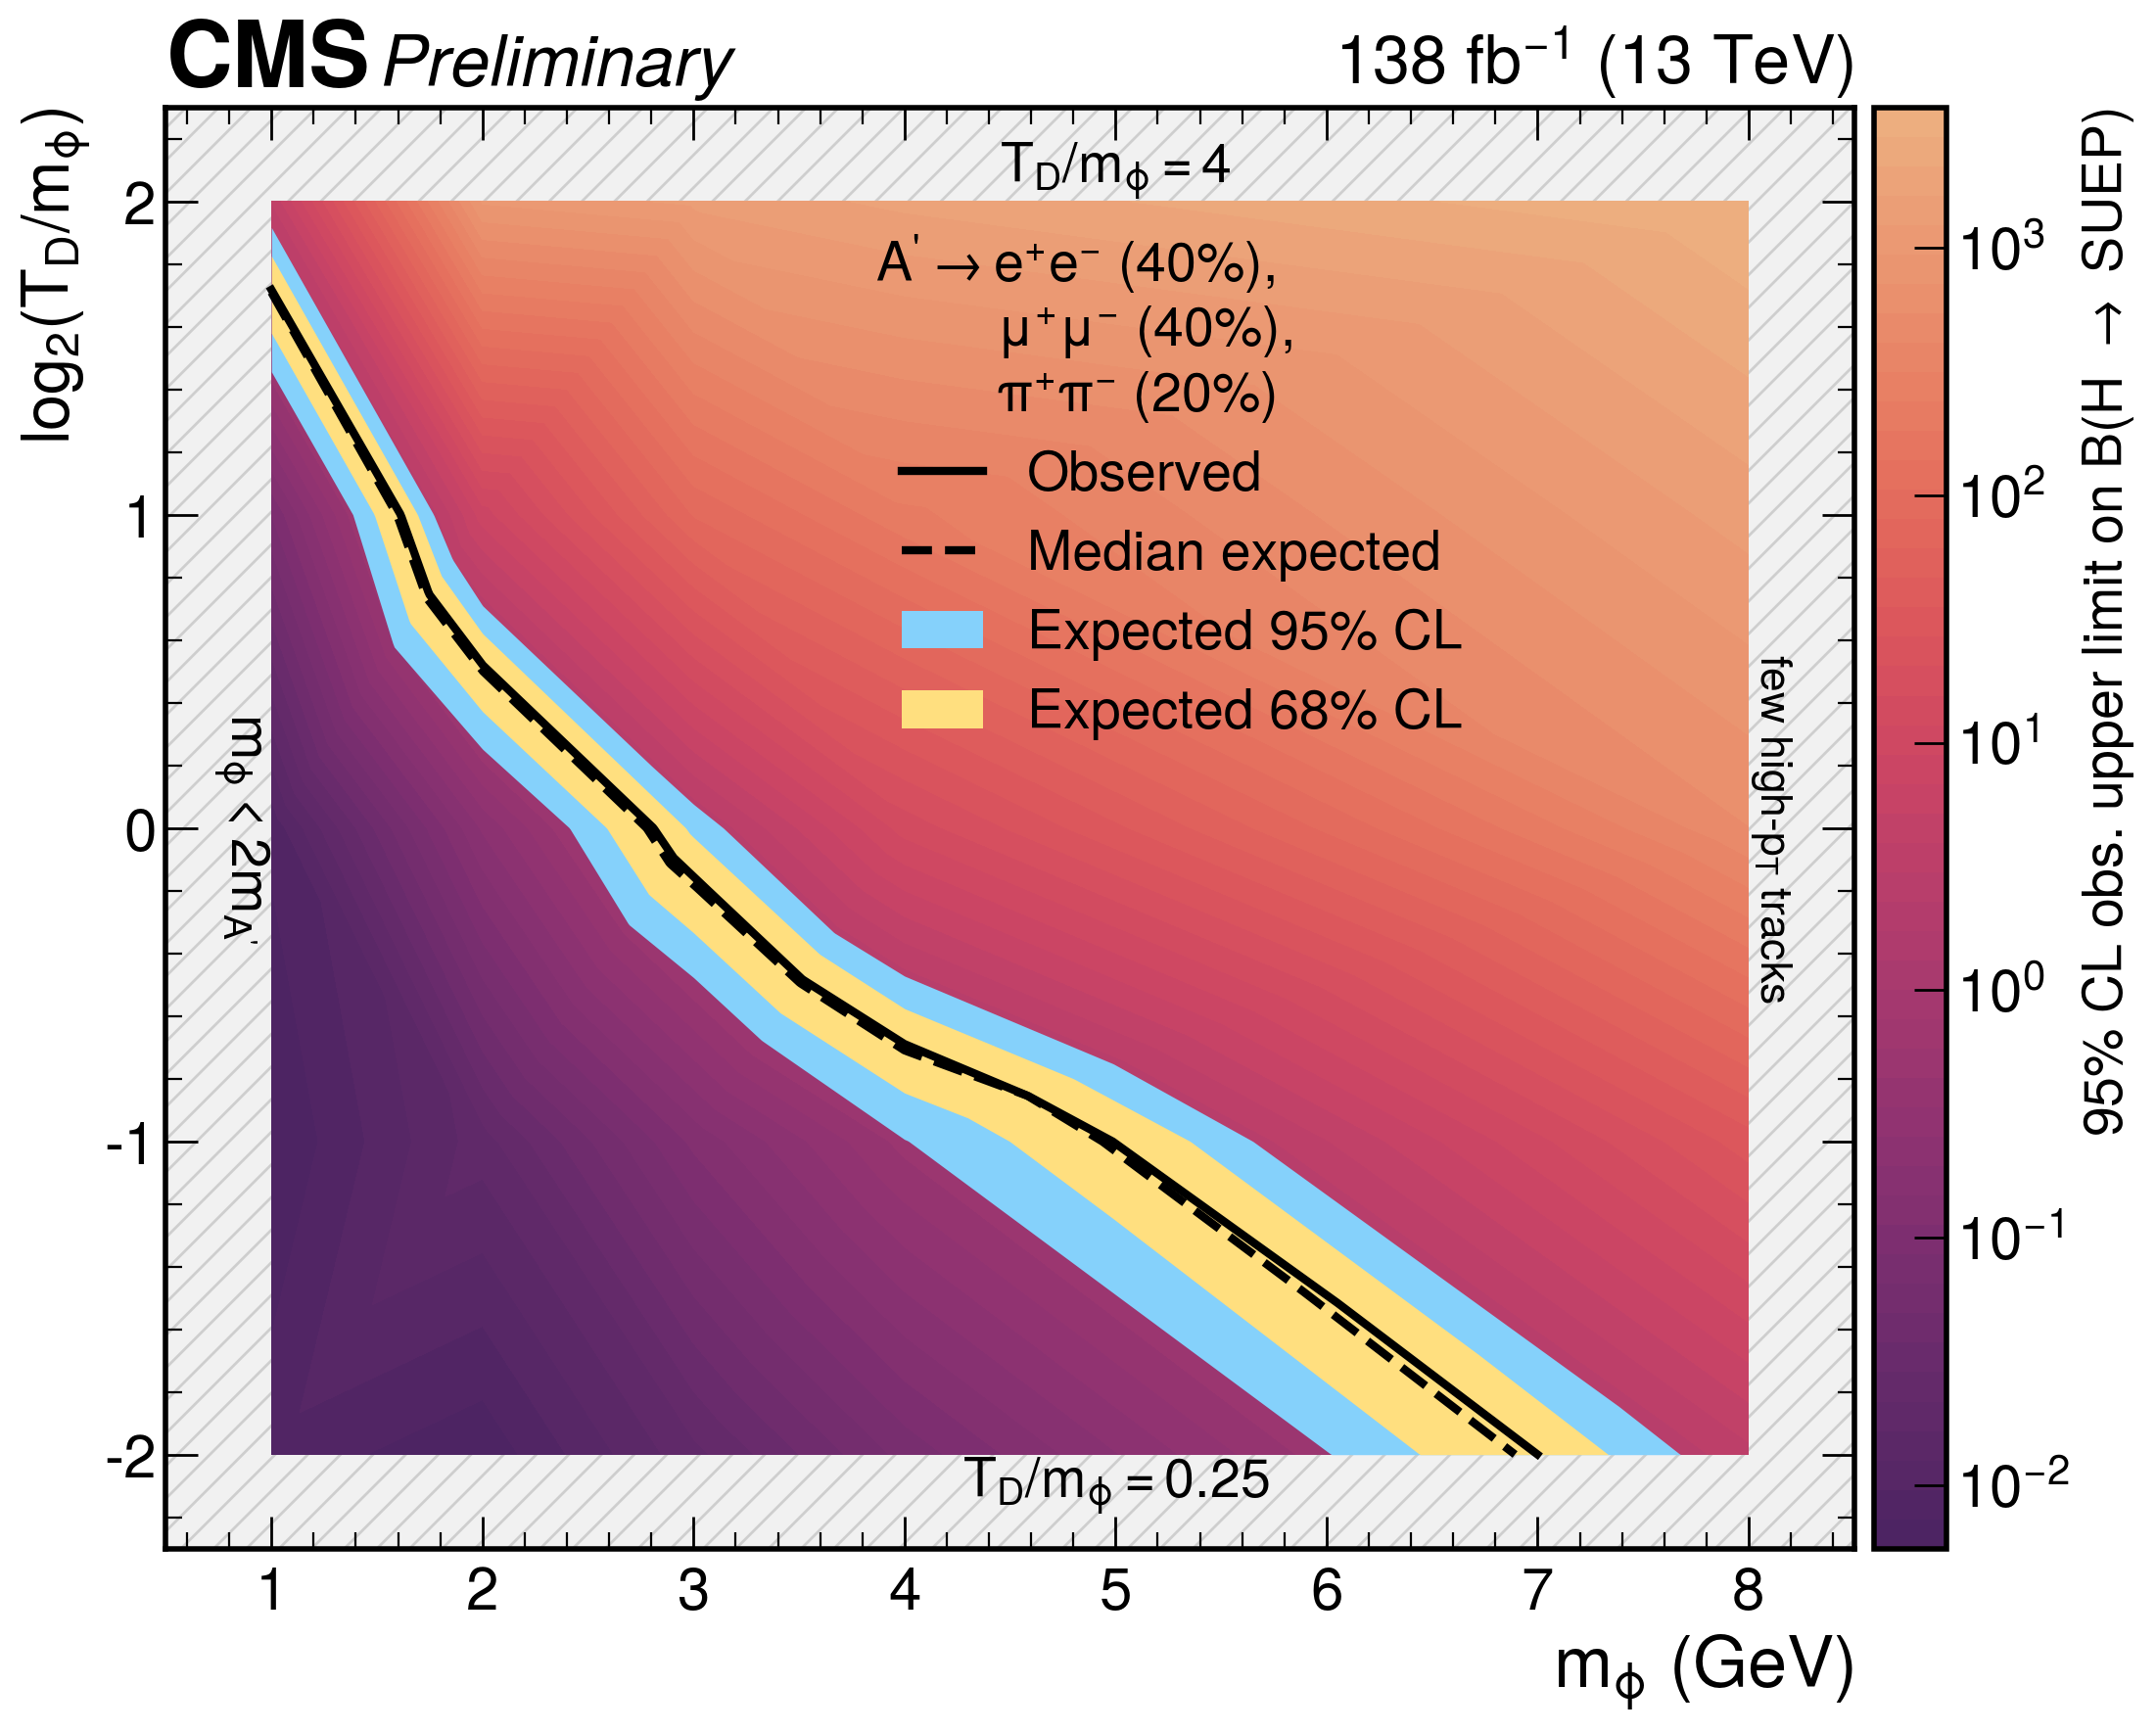

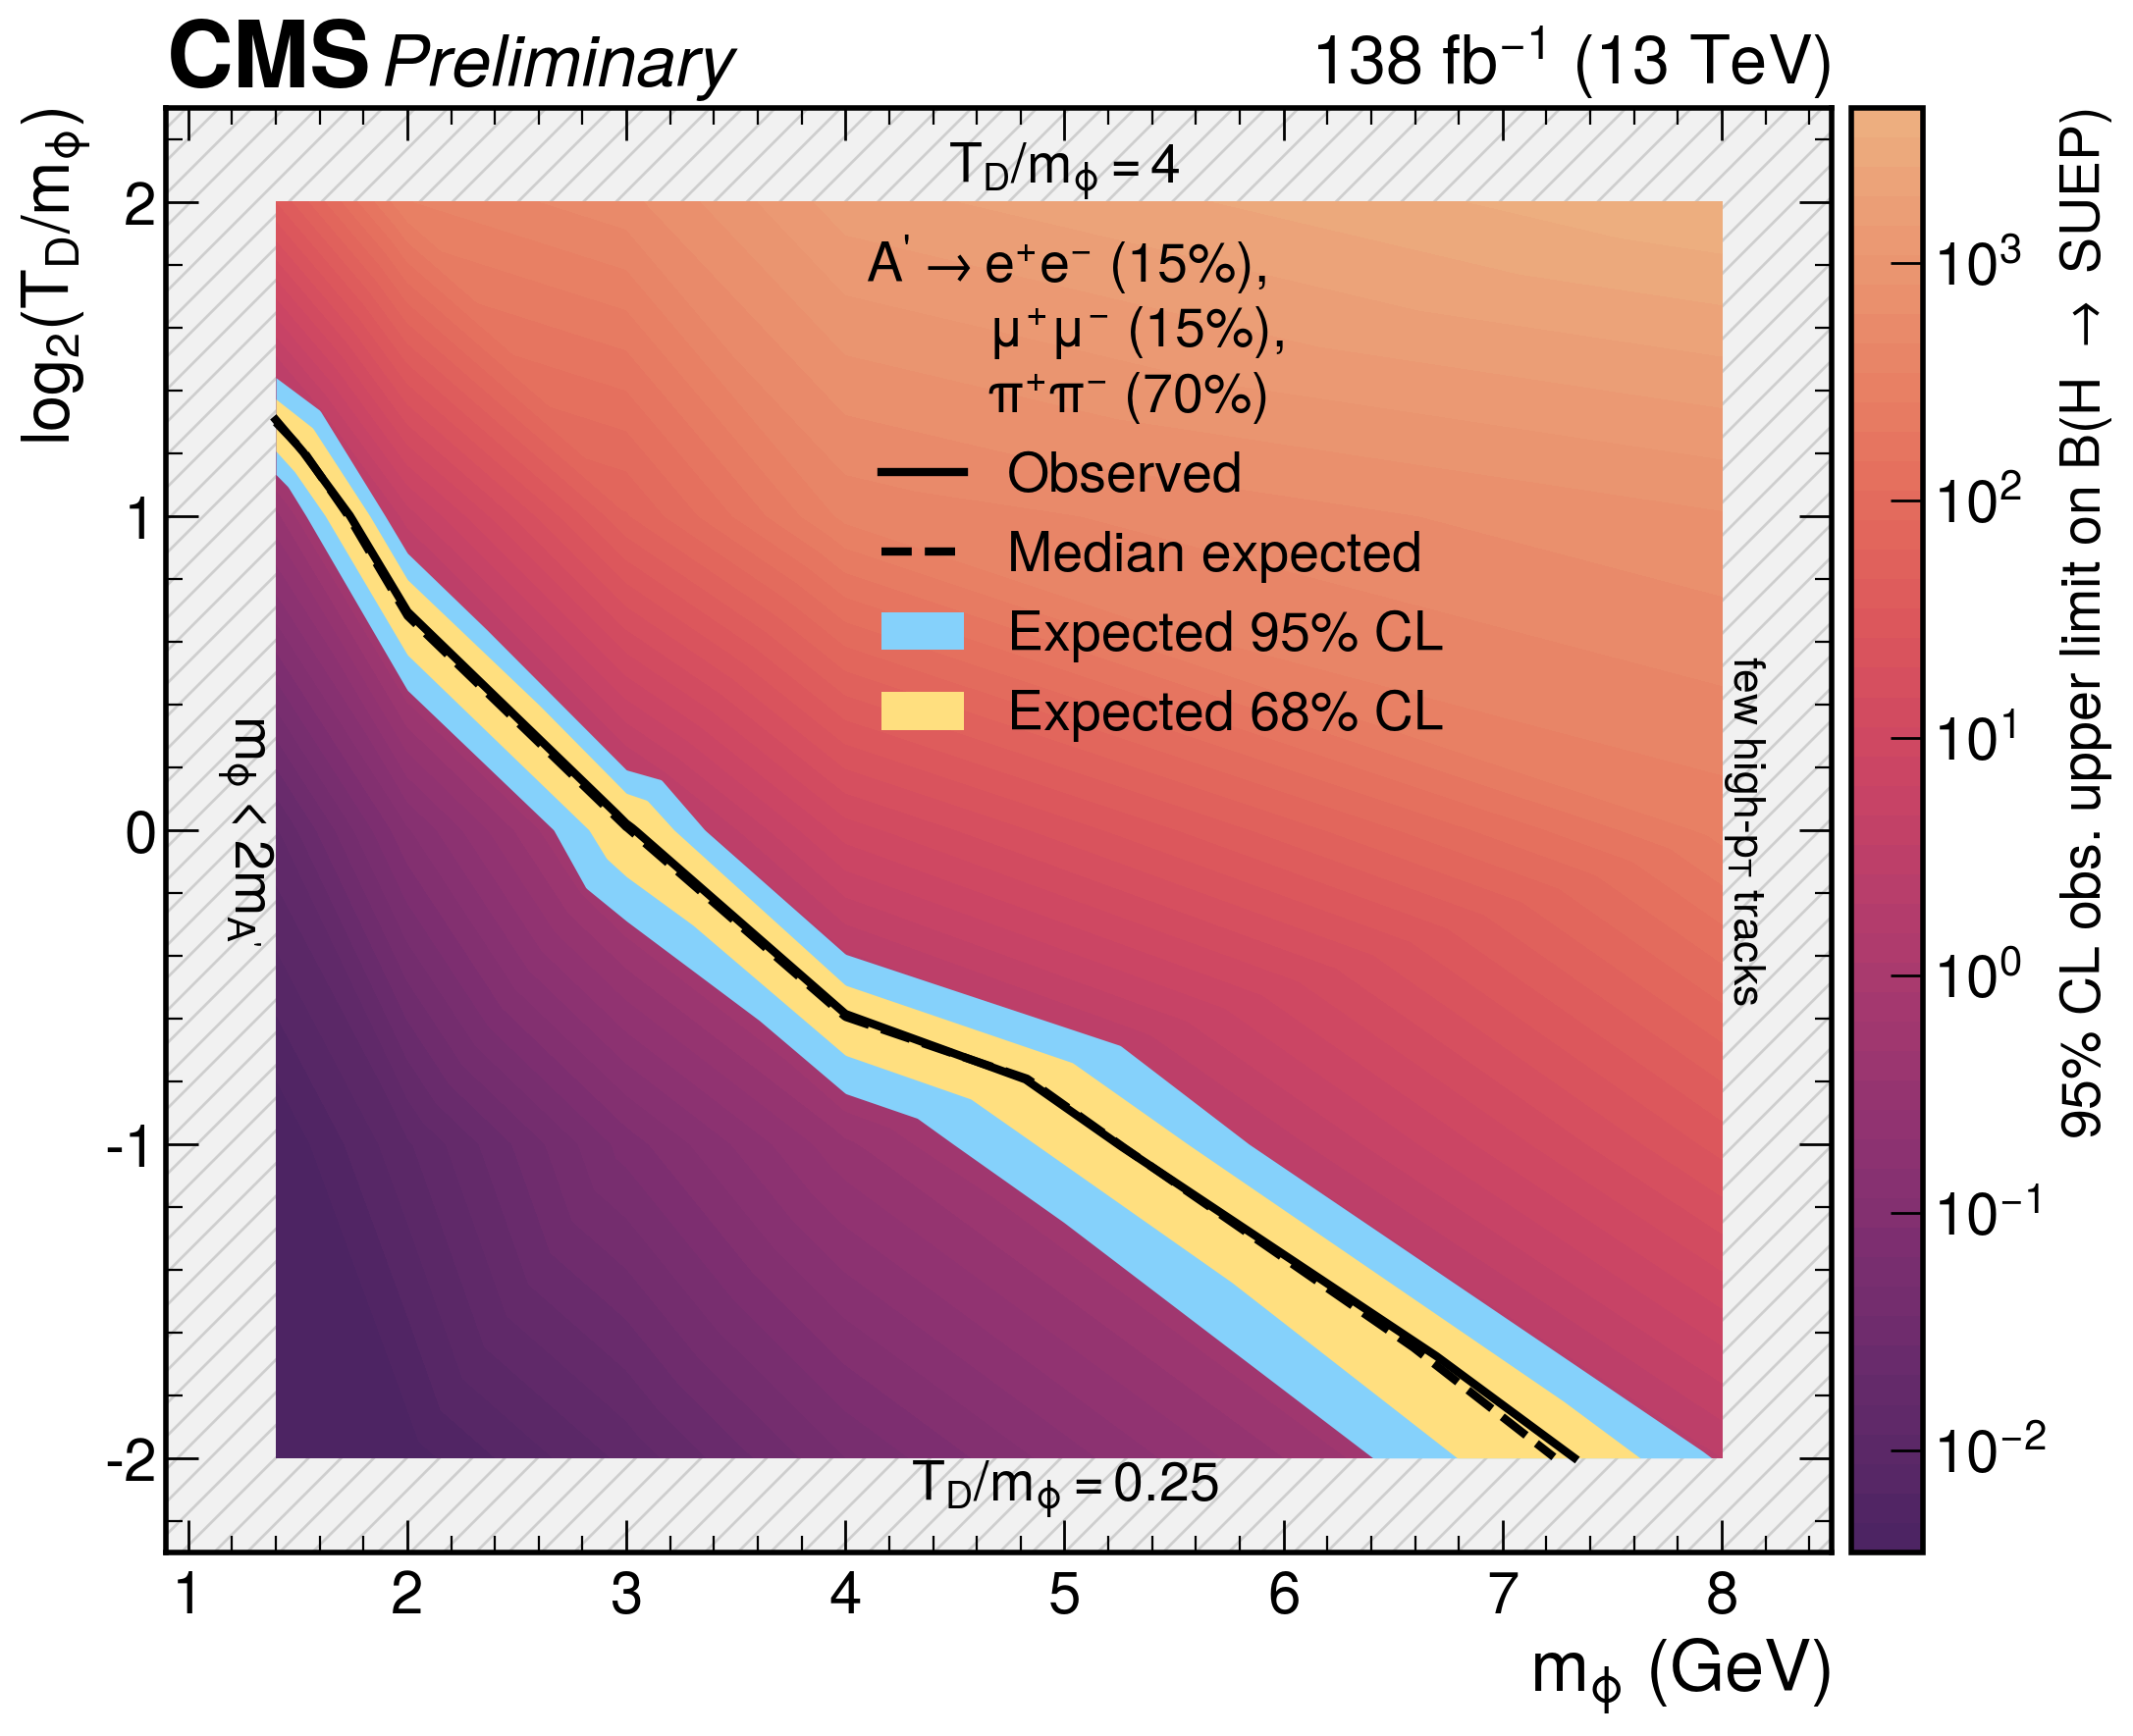

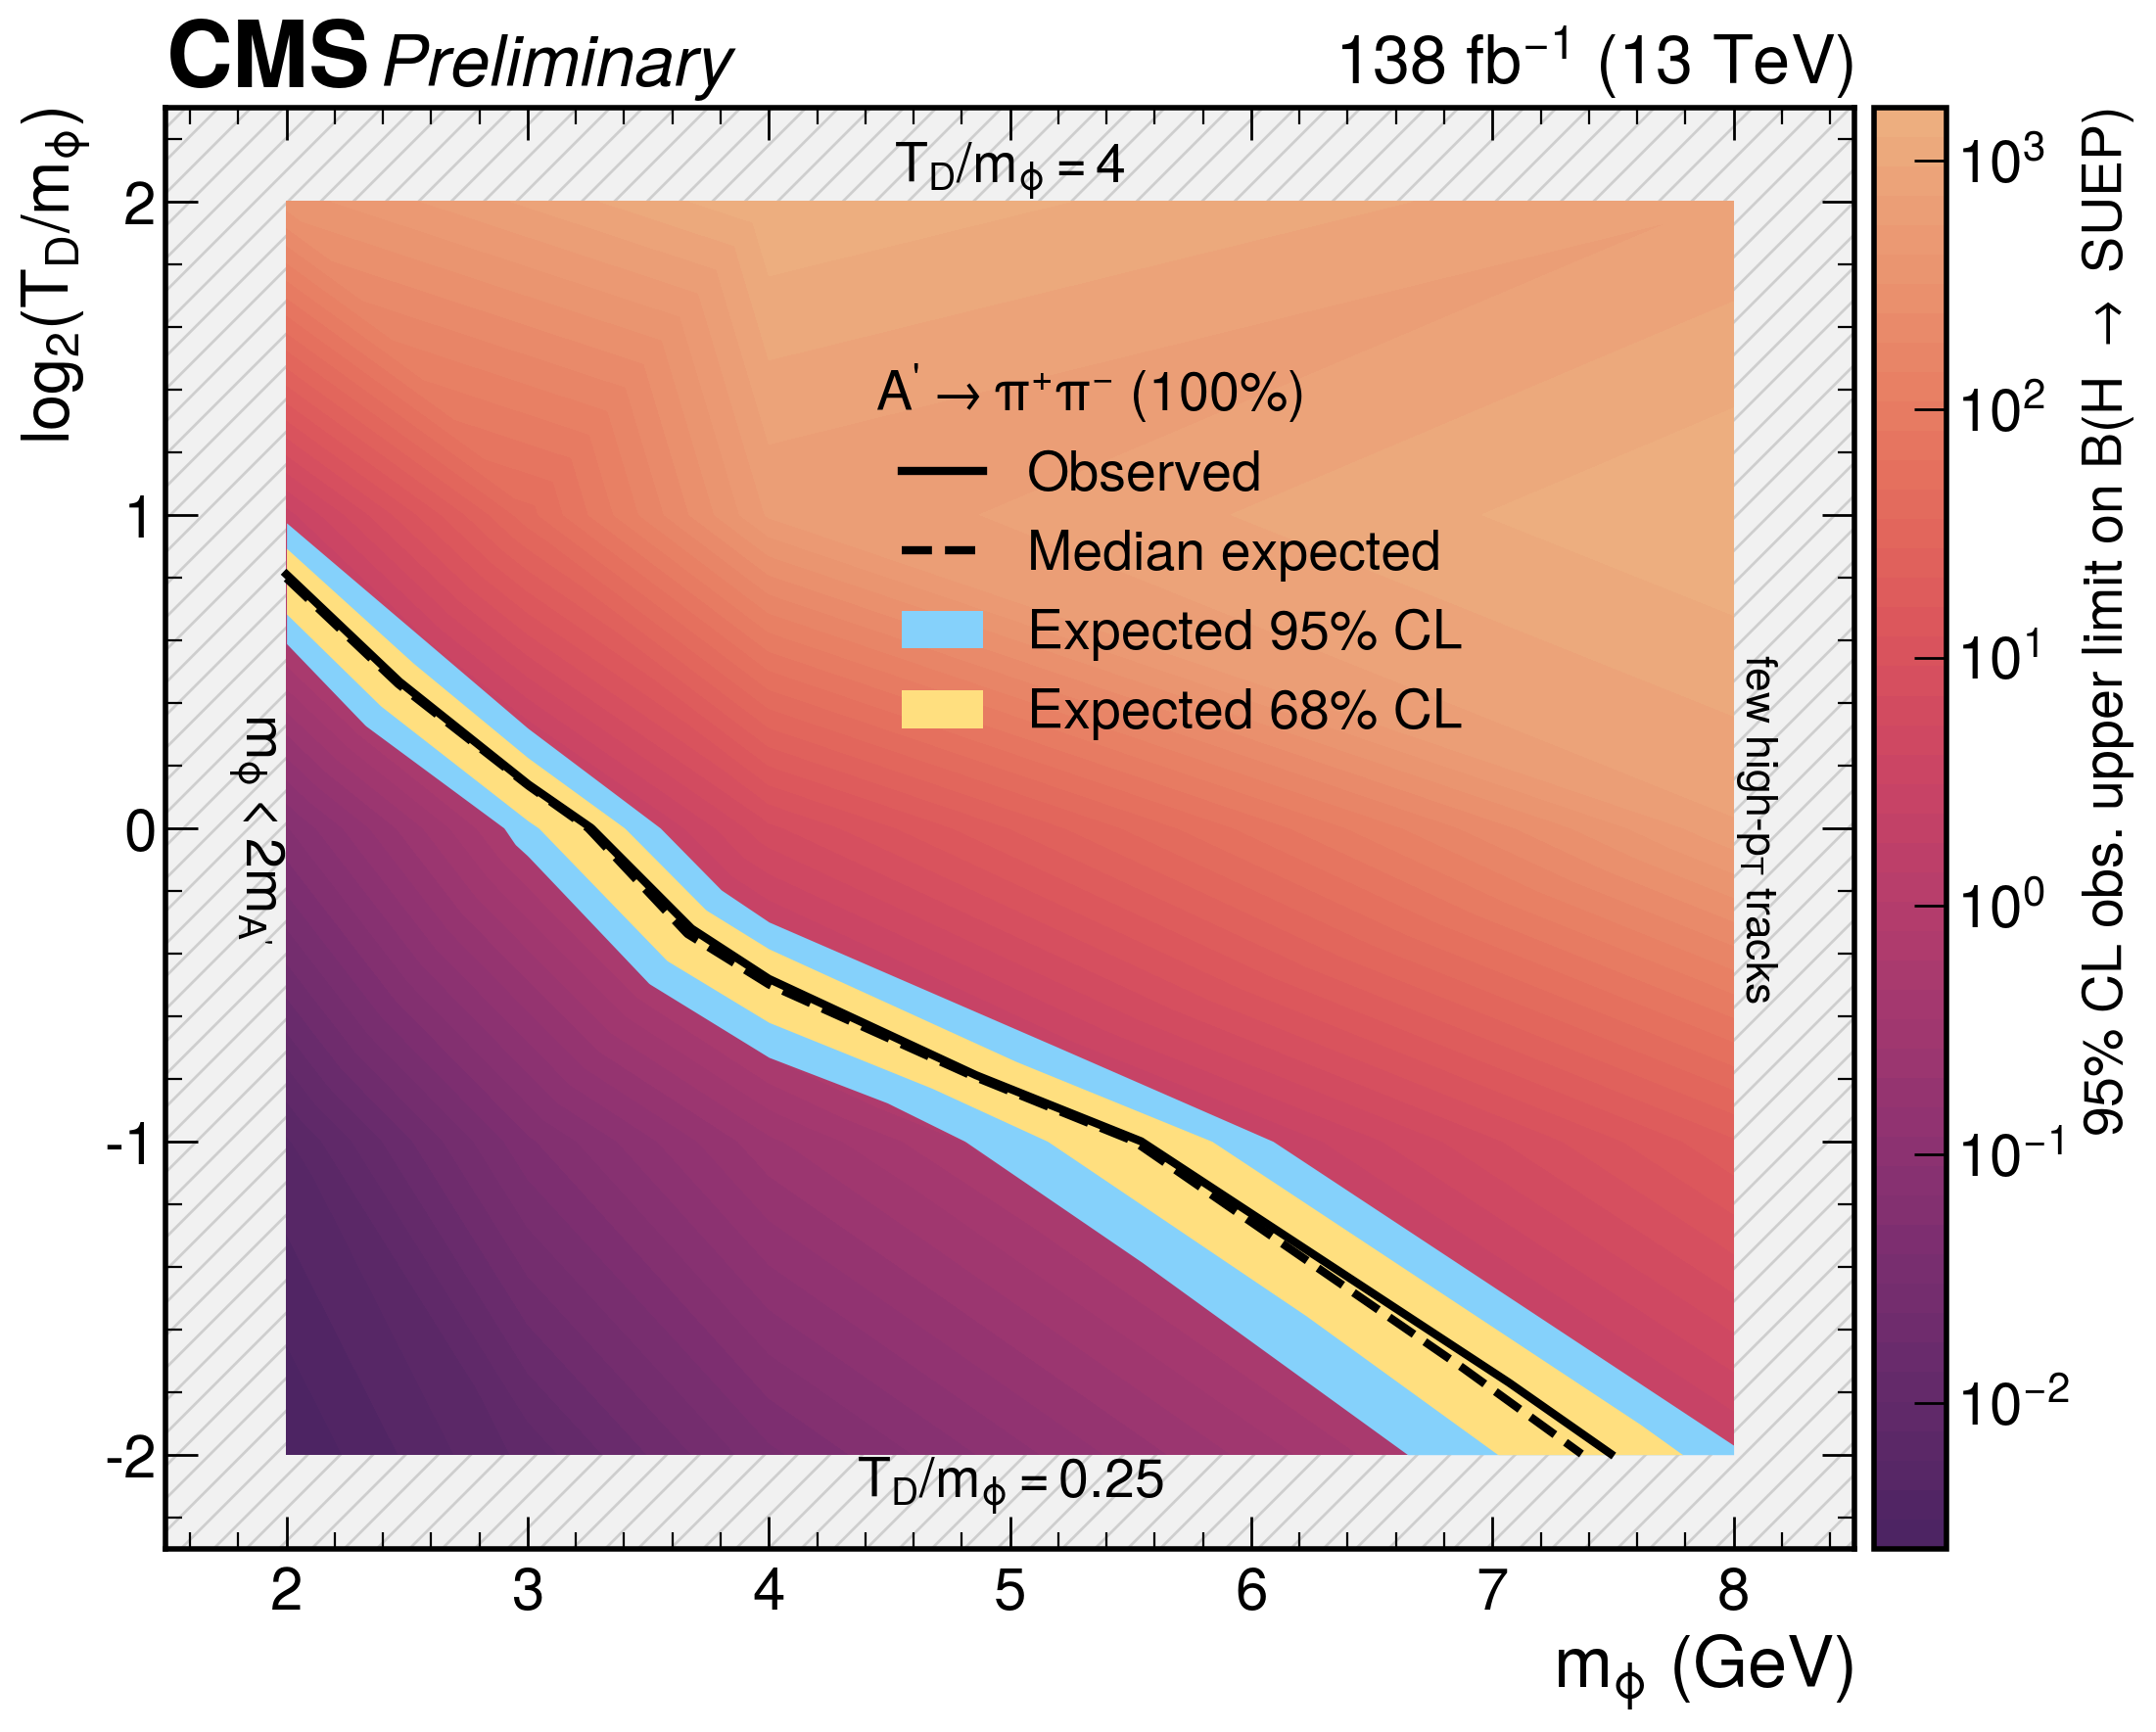

In [55]:
# example usage of the 2D limits function
decay_modes = [
    'leptonic',
    'hadronic',
    'generic'
]

for decay_mode in decay_modes:
    fig = plot_mPhi_temp_limits(
        ms=125, analysis='wh', decay=decay_mode,
        path='../cards/WH_3_9/', method='AsymptoticLimits',
        tricontour='log', showPoints=False, showObserved=True, showTheoryLines=False, cmsLabel=False, muLimit=True, T_by_mPhi=True
    )
    ax = fig.get_axes()[0]
    _ = hep.cms.label(data=True, llabel='Preliminary', lumi=utils.lumis['combined'], ax=fig.get_axes()[0])

    cbar = fig.get_axes()[-1]  # Assuming the colorbar is the last axis in the figure
    cbar.set_ylabel(r'$95\%$ CL obs. upper limit on B(H $\rightarrow$ SUEP)', fontsize=20)

    ax.set_ylim(-2.3, 2.3)
    ax.set_xlim(utils.mA[decay_mode]*2-0.5, 8.5)

    ax.set_ylabel("$\mathrm{log}_2(T_D/m_{\phi})$", fontsize=24)

    # Find all text objects in the figure
    for txt in fig.findobj(plt.Text):
        text = txt.get_text()
        if r"m_{s}" in text: 
            txt.remove()
            _ = ax.text(
                0.42, 0.78, r"{}".format(utils.decaysLabelsWithLineBreaks[decay_mode]),
                fontsize=20, horizontalalignment='left', 
                verticalalignment='bottom', 
                transform=ax.transAxes
            )
    # lower the legend
    ax.legend(loc='upper right', bbox_to_anchor=(0.8, 0.8), fontsize=20)

    # Add a shaded rectangle that fills the whole figure but goes underneath everything else
    rect = plt.Rectangle(
        (ax.get_xlim()[0], ax.get_ylim()[0]),  # Bottom-left corner
        width=ax.get_xlim()[1] - ax.get_xlim()[0],  # Width of the rectangle
        height=ax.get_ylim()[1] - ax.get_ylim()[0],  # Height of the rectangle
        transform=ax.transData, facecolor='lightgray', edgecolor='gray', alpha=0.3, zorder=-1,
        hatch='//'
    )
    ax.add_patch(rect)

    ax.text(8, 0, 'few high-$p_T$ tracks', horizontalalignment='left', verticalalignment='center',fontsize=16,rotation=-90)
    ax.text(2*utils.mA[decay_mode], 0, r"$m_{\phi}<2m_{A^'}$", horizontalalignment='right', verticalalignment='center',fontsize=20,rotation=-90)
    ax.text(5, 2, r'$T_D/m_{\phi}=4$', horizontalalignment='center', verticalalignment='bottom',fontsize=20,rotation =0)
    ax.text(5, -2, r'$T_D/m_{\phi}=0.25$', horizontalalignment='center', verticalalignment='top',fontsize=20,rotation=0)

    if saveToAN:
        fig.savefig(outDirAN + fig.get_label() + '.pdf', bbox_inches='tight')
    if True:
        fig.savefig(outDirPAS + fig.get_label() + '.pdf', bbox_inches='tight')

    #fig.savefig(outDir + fig.get_label() + '.png', bbox_inches='tight', dpi=300)

## PAS: log(T/mD) ZH style 1D limits

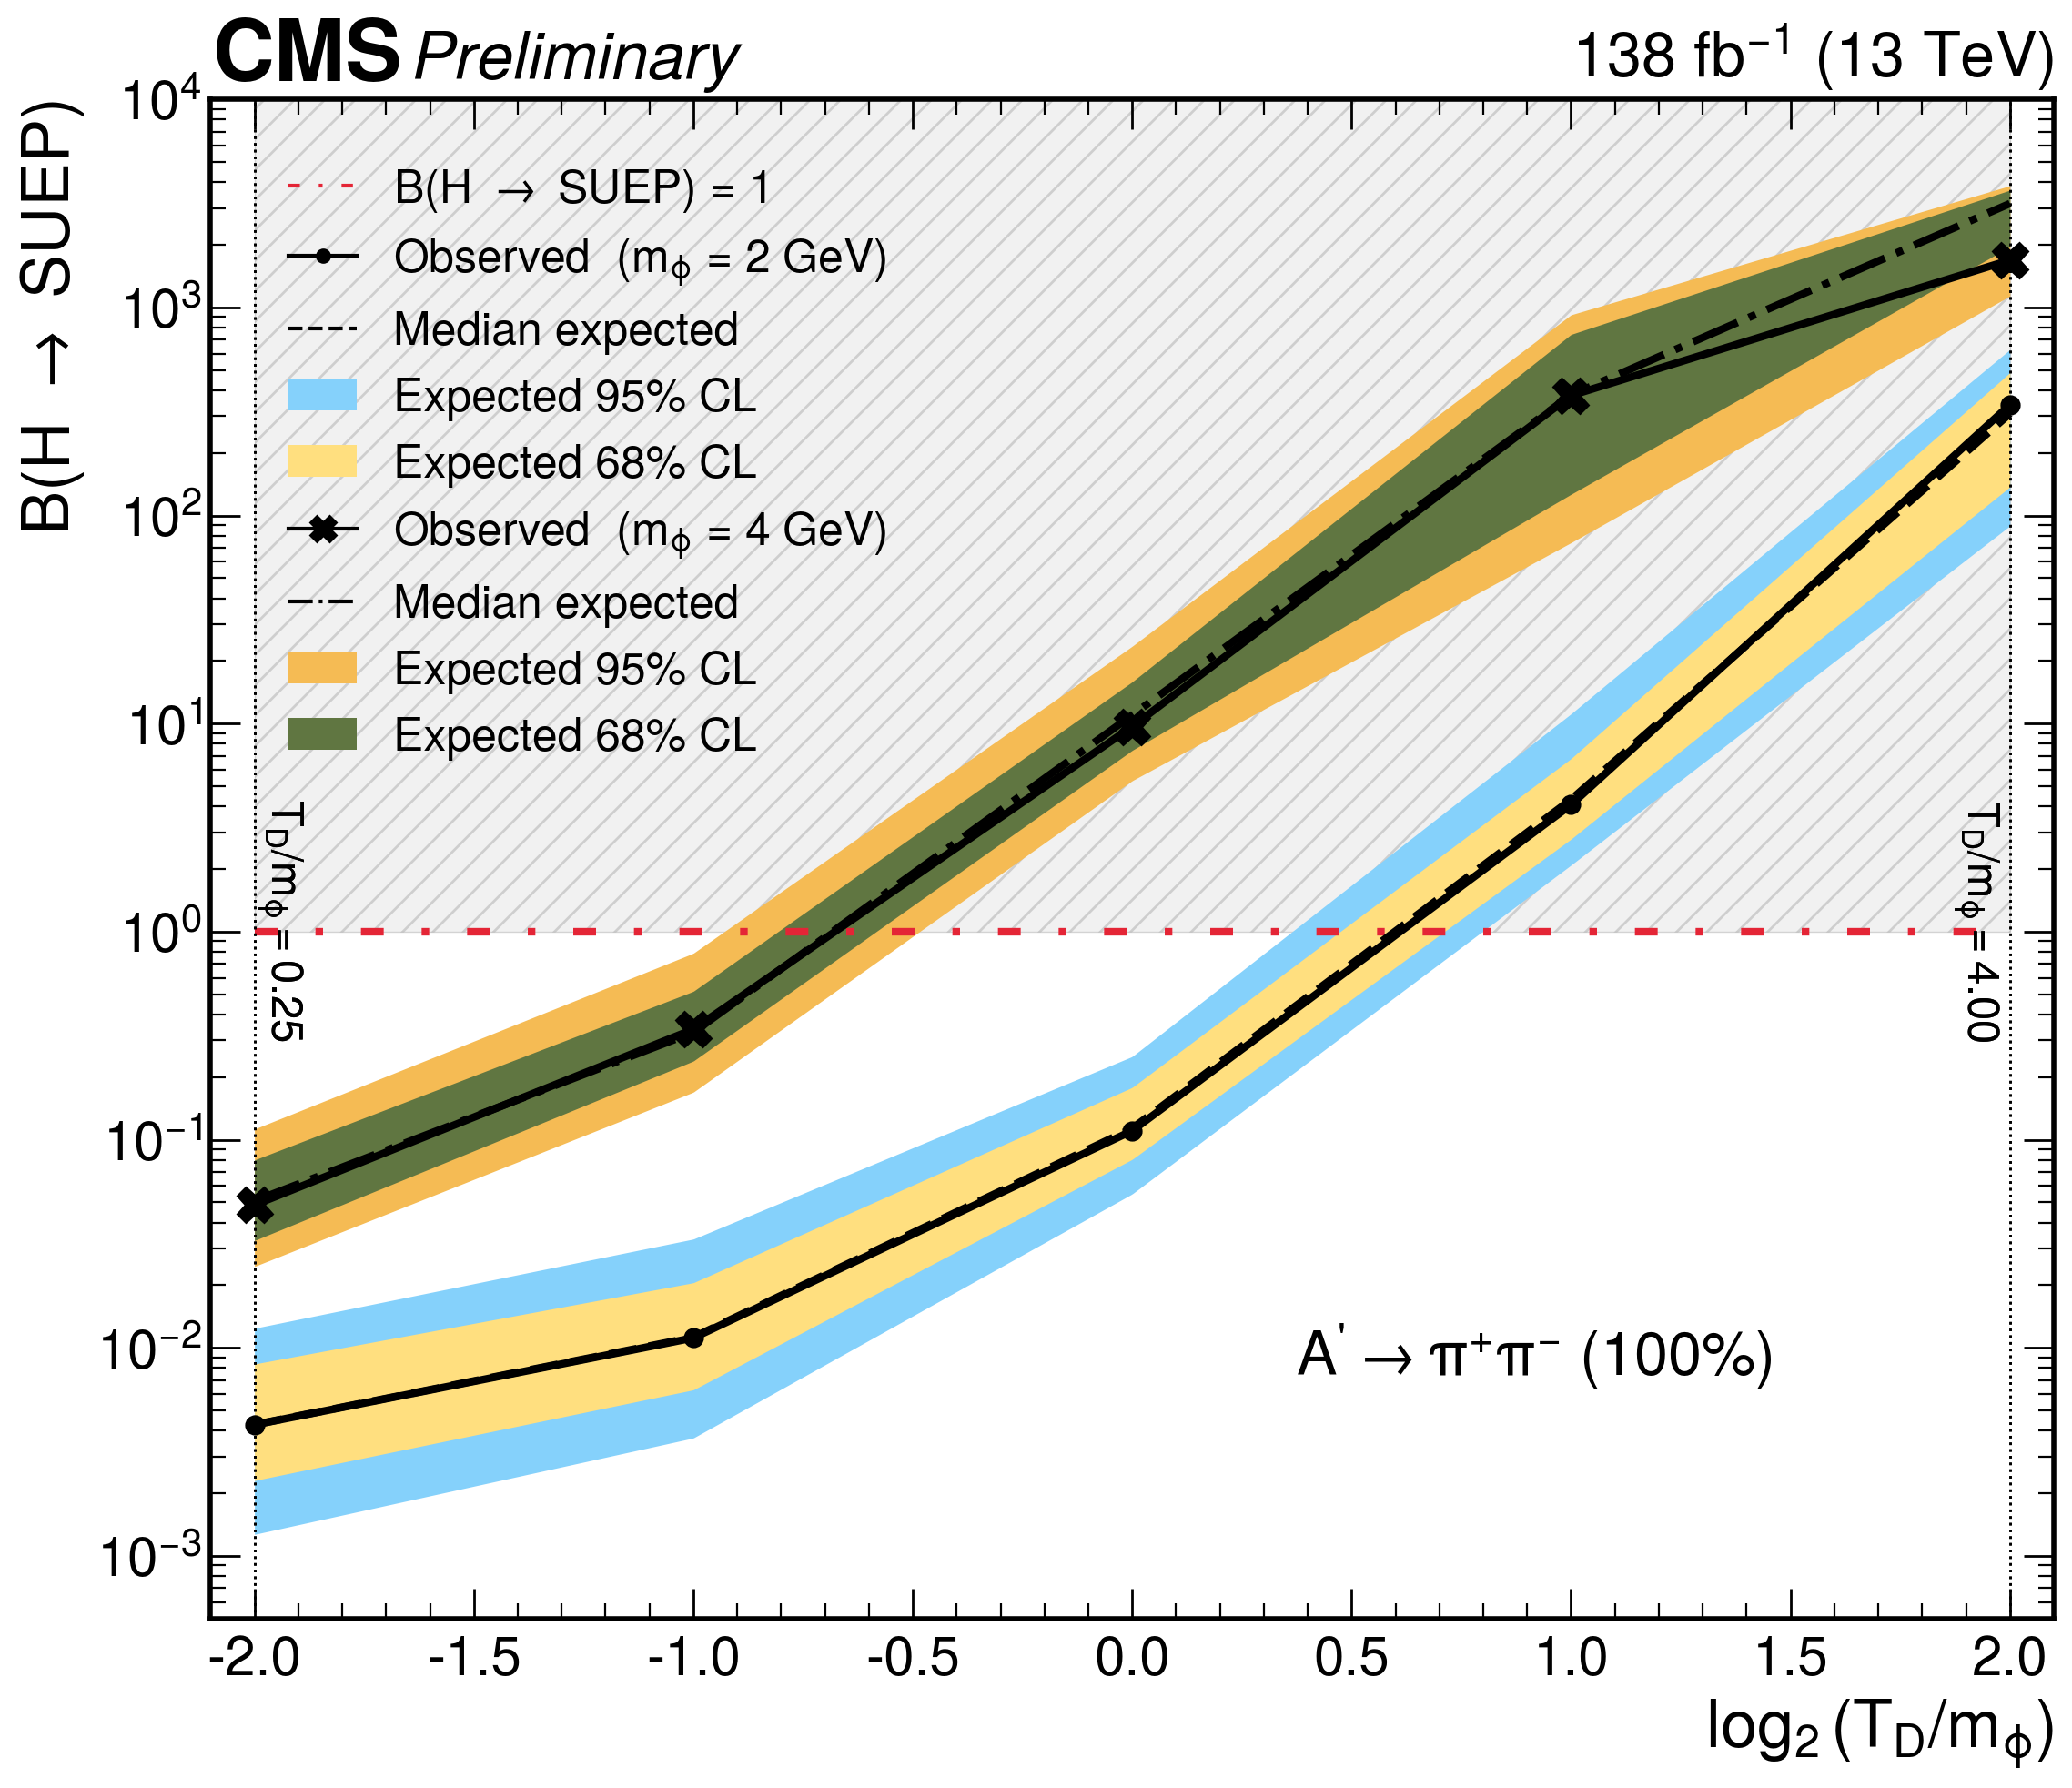

In [49]:
import matplotlib.ticker as ticker
import numpy as np
fig = utils.plot_limits_log2T_by_mD(
    mD=2.000, ms=125, decay='hadronic',
    path='../cards/WH_3_9/', method='AsymptoticLimits', analysis='wh',
    obs_marker='.', exp_linestyle='--', bands_cmap='cms', mu_limit=True,  legend_label_postfix=' ($m_{\phi}$ = 2 GeV)'
)
ax = utils.plot_limits_log2T_by_mD(
    mD=4.000, ms=125, decay='hadronic',
    path='../cards/WH_3_9/', method='AsymptoticLimits', analysis='wh',
    obs_marker='X', exp_linestyle='-.', bands_cmap='yellow_green', mu_limit=True, ax=fig.axes[0], legend_label_postfix=' ($m_{\phi}$ = 4 GeV)'
)
#ax = utils.plot_mphi_by_T_limits(temp_by_mphi=1.0, ms=125, decay='hadronic', path='../official-combined/WH/', color='green', obs_marker='x', bands=False, exp_alpha=0.5, method='AsymptoticLimits', analysis='wh', mu_limit=True, ax=fig.axes[0], all_decays=True)
#ax = utils.plot_mphi_by_T_limits(temp_by_mphi=1.0, ms=125, decay='leptonic', path='../official-combined/WH/', color='orange', obs_marker='^', bands=False, exp_alpha=0.5, method='AsymptoticLimits', analysis='wh', mu_limit=True, ax=fig.axes[0], all_decays=True)

hep.cms.label(data=True, llabel='Preliminary', lumi=utils.lumis['combined'], ax=fig.get_axes()[0])

# ax.set_ylim(top=1e7)
ax.set_ylim(5e-4, 1e4)

# ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=20))
# ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation())

# # Set minor ticks explicitly to appear (2-9 between each power of 10)
# ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=10))

# # Suppress minor tick labels
# ax.yaxis.set_minor_formatter(ticker.NullFormatter())

#fig.set_size_inches(12, 10, forward=True)

# Add a rectangle to cover the top-right space
rect = plt.Rectangle((-2, 1), width=4, height=ax.get_ylim()[1], 
                      transform=ax.transData, facecolor='lightgray', edgecolor='gray', alpha=0.3, linewidth=0.5, zorder=0, hatch='//')
rect.set_rasterized(True)
ax.add_patch(rect)

_ = ax.text(
    0.85, 0.15, utils.decaysLabelsWithLineBreaks['generic'],
    fontsize=24, horizontalalignment='right', 
    verticalalignment='bottom', 
    transform=ax.transAxes,
)

handles, labels = fig.get_axes()[0].get_legend_handles_labels()
fig.get_axes()[0].legend(handles, labels, loc=(0.03, 0.55), fontsize=18, ncol=1)

if saveToPAS:
    fig.savefig(outDirPAS + "limits_log2TovermPhi_mPhi_2_4" + '.pdf', bbox_inches='tight')

#fig.savefig(outDir + "limits_log2TovermPhi_mPhi_2_4" + '.png', bbox_inches='tight', dpi=300)

plt.show()

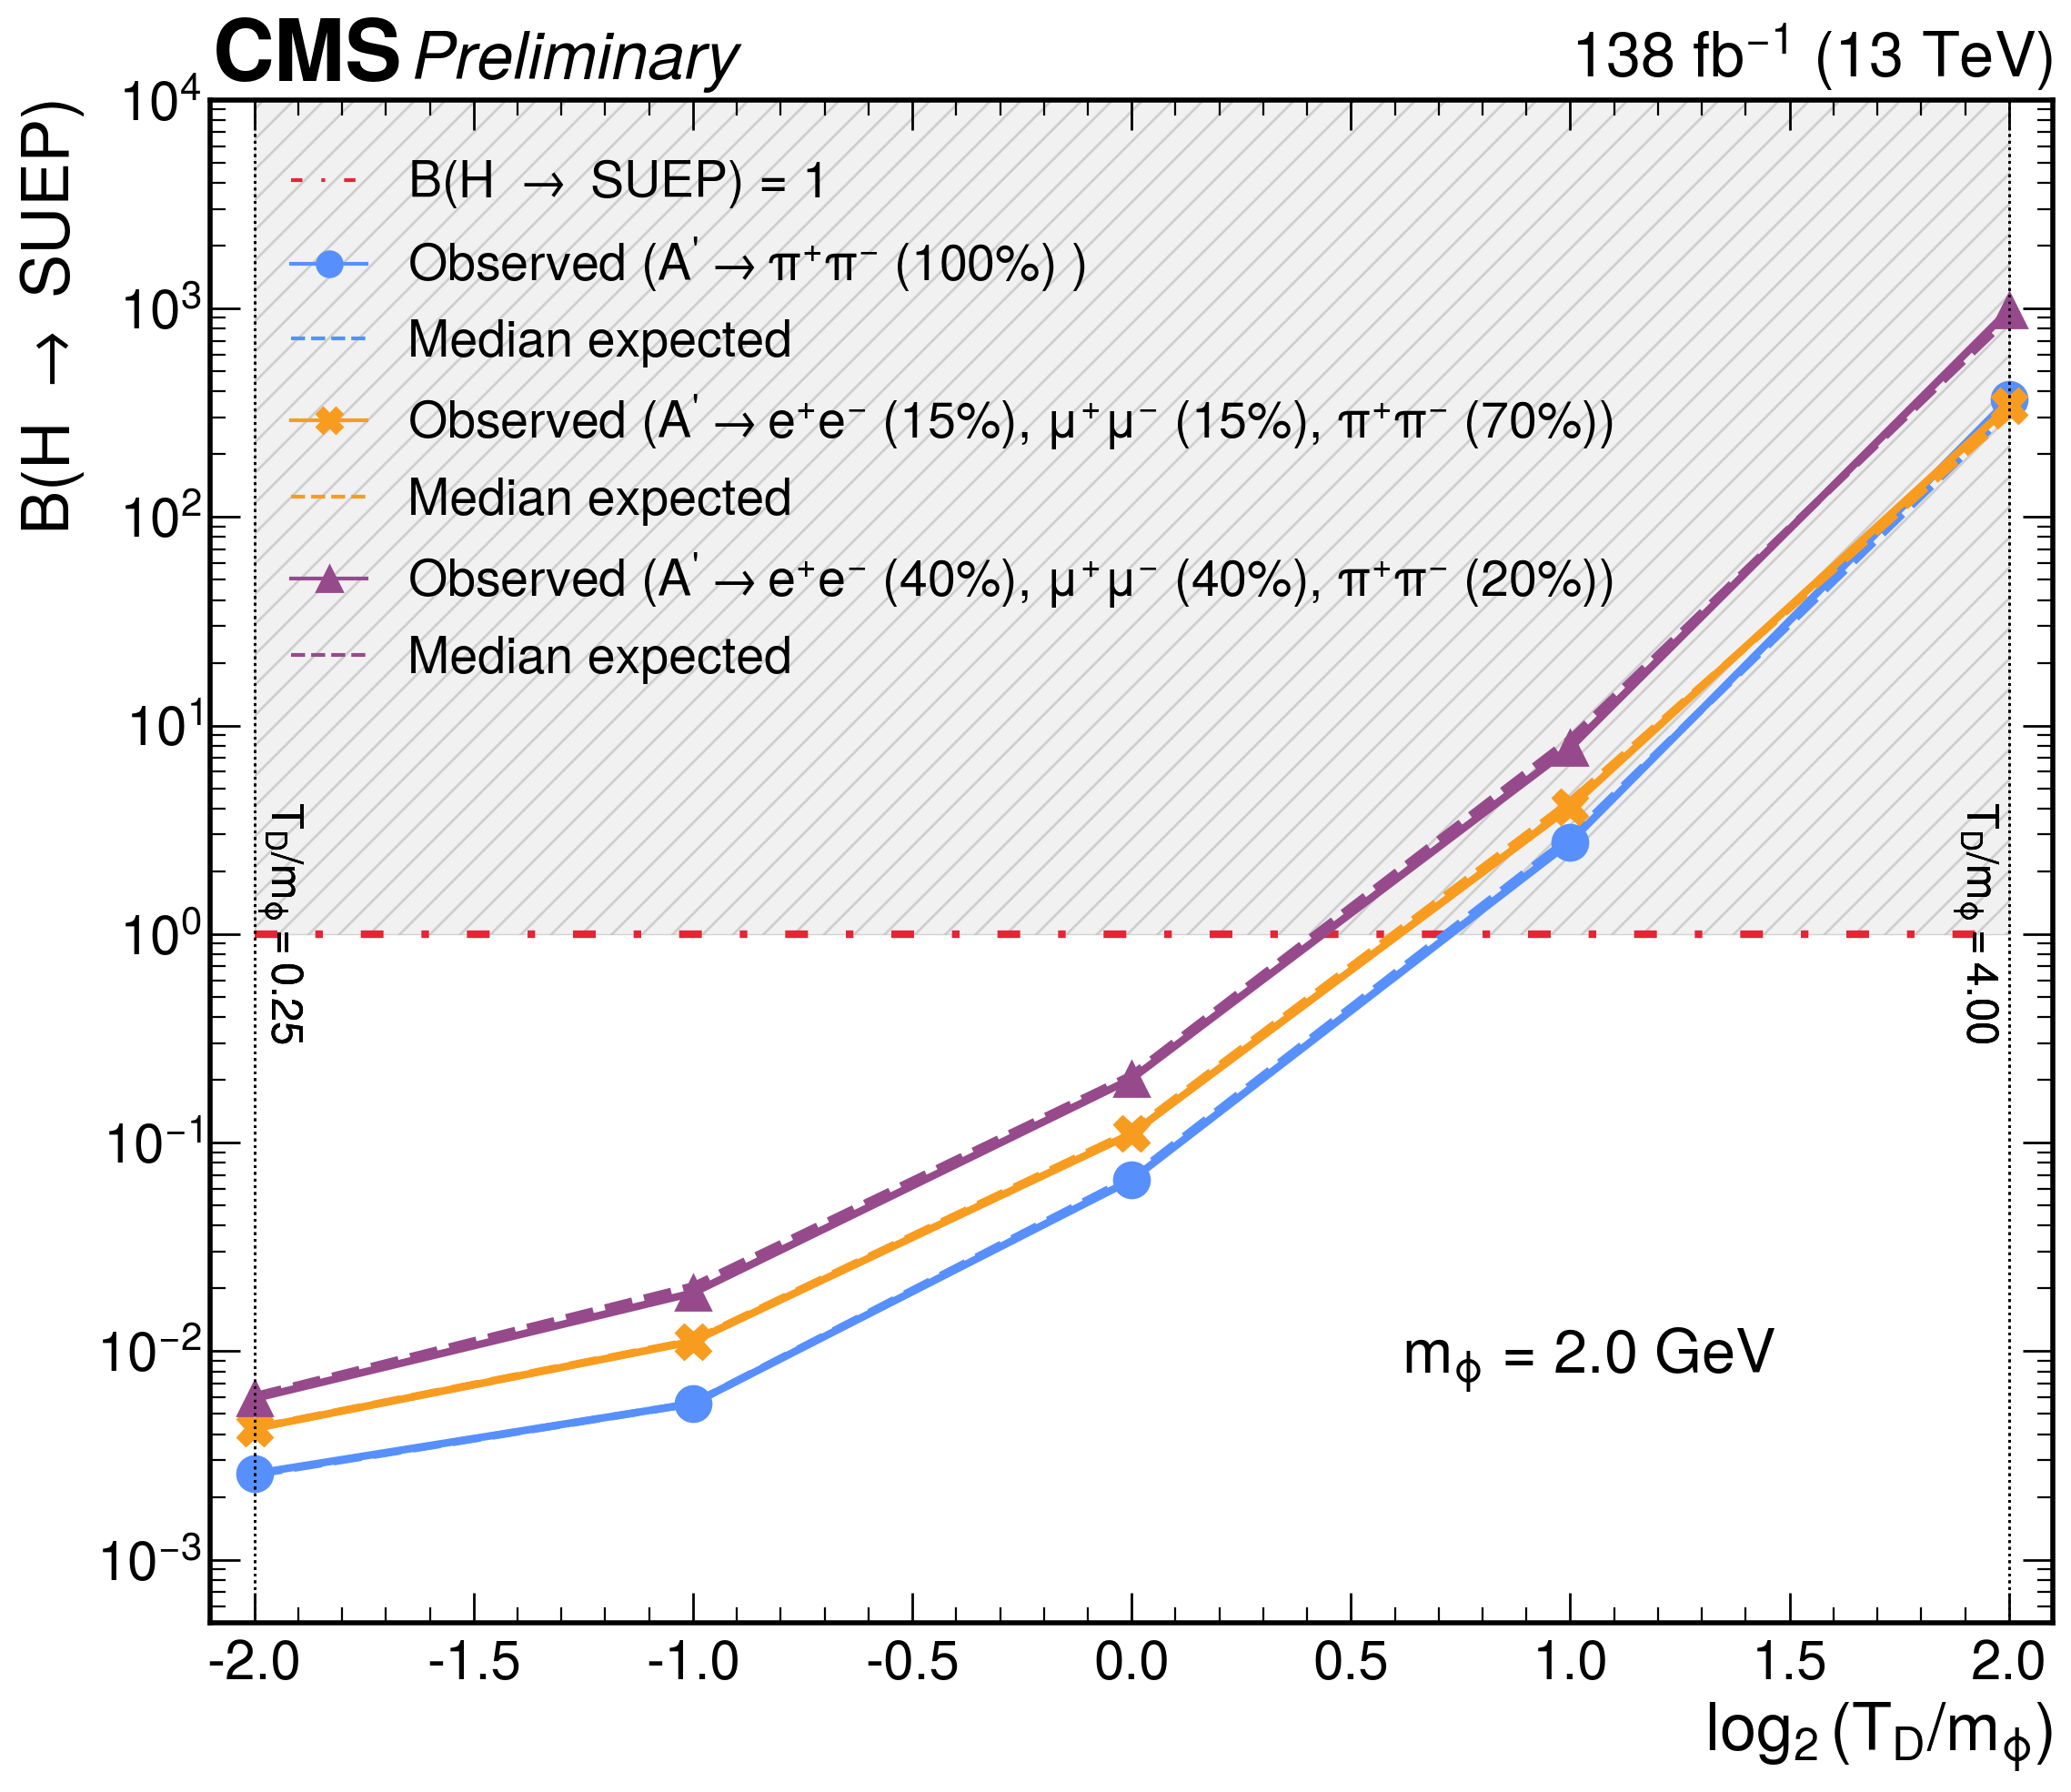

In [5]:
fig = utils.plot_limits_log2T_by_mD(mD=2.000, ms=125, decay='generic', path='../cards/WH_3_9/', color="#5790fc", obs_marker='o', bands=False, method='AsymptoticLimits', analysis='wh', mu_limit=True, all_decays=True)
ax = utils.plot_limits_log2T_by_mD(mD=2.000, ms=125, decay='hadronic', path='../cards/WH_3_9/', color='#f89c20', obs_marker='X', bands=False, method='AsymptoticLimits', analysis='wh', mu_limit=True, ax=fig.axes[0], all_decays=True)
ax = utils.plot_limits_log2T_by_mD(mD=2.000, ms=125, decay='leptonic', path='../cards/WH_3_9/', color='#964a8b', obs_marker='^', bands=False, method='AsymptoticLimits', analysis='wh', mu_limit=True, ax=fig.axes[0], all_decays=True)

# label
hep.cms.label(data=True, llabel='Preliminary', lumi=utils.lumis['combined'], ax=fig.get_axes()[0])

# y limit and ticks
ax.set_ylim(5e-4, 1e4)

ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=20))
ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation())

# Set minor ticks explicitly to appear (2-9 between each power of 10)
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=10))

# Suppress minor tick labels
ax.yaxis.set_minor_formatter(ticker.NullFormatter())

# Add a rectangle to cover the top-right space
rect = plt.Rectangle((-2, 1), width=4, height=ax.get_ylim()[1], 
                      transform=ax.transData, facecolor='lightgray', edgecolor='gray', alpha=0.3, linewidth=0.5, zorder=0, hatch='//')
rect.set_rasterized(True)
ax.add_patch(rect)

# legend
handles, labels = fig.get_axes()[0].get_legend_handles_labels()
labels[1] = 'Observed (' + utils.decaysLabels['generic'] + ')'
labels[3] = 'Observed (' + utils.decaysLabels['hadronic'] + ')'
labels[5] = 'Observed (' + utils.decaysLabels['leptonic'] + ')'
fig.get_axes()[0].legend(handles, labels, loc=(0.03, 0.60), fontsize=20, ncol=1)

_ = ax.text(
    0.85, 0.15, "$m_{{\phi}}$ = {} GeV".format(2.000),
    fontsize=24, horizontalalignment='right', 
    verticalalignment='bottom', 
    transform=ax.transAxes,
)

if saveToPAS:
    fig.savefig(outDirPAS + "limits_log2TovermPhi_mPhi_2_mA_all" + '.pdf', bbox_inches='tight', dpi=300)

fig.savefig(outDir + "limits_log2TovermPhi_mPhi_2_mA_all" + '.png', bbox_inches='tight', dpi=300)

plt.show()

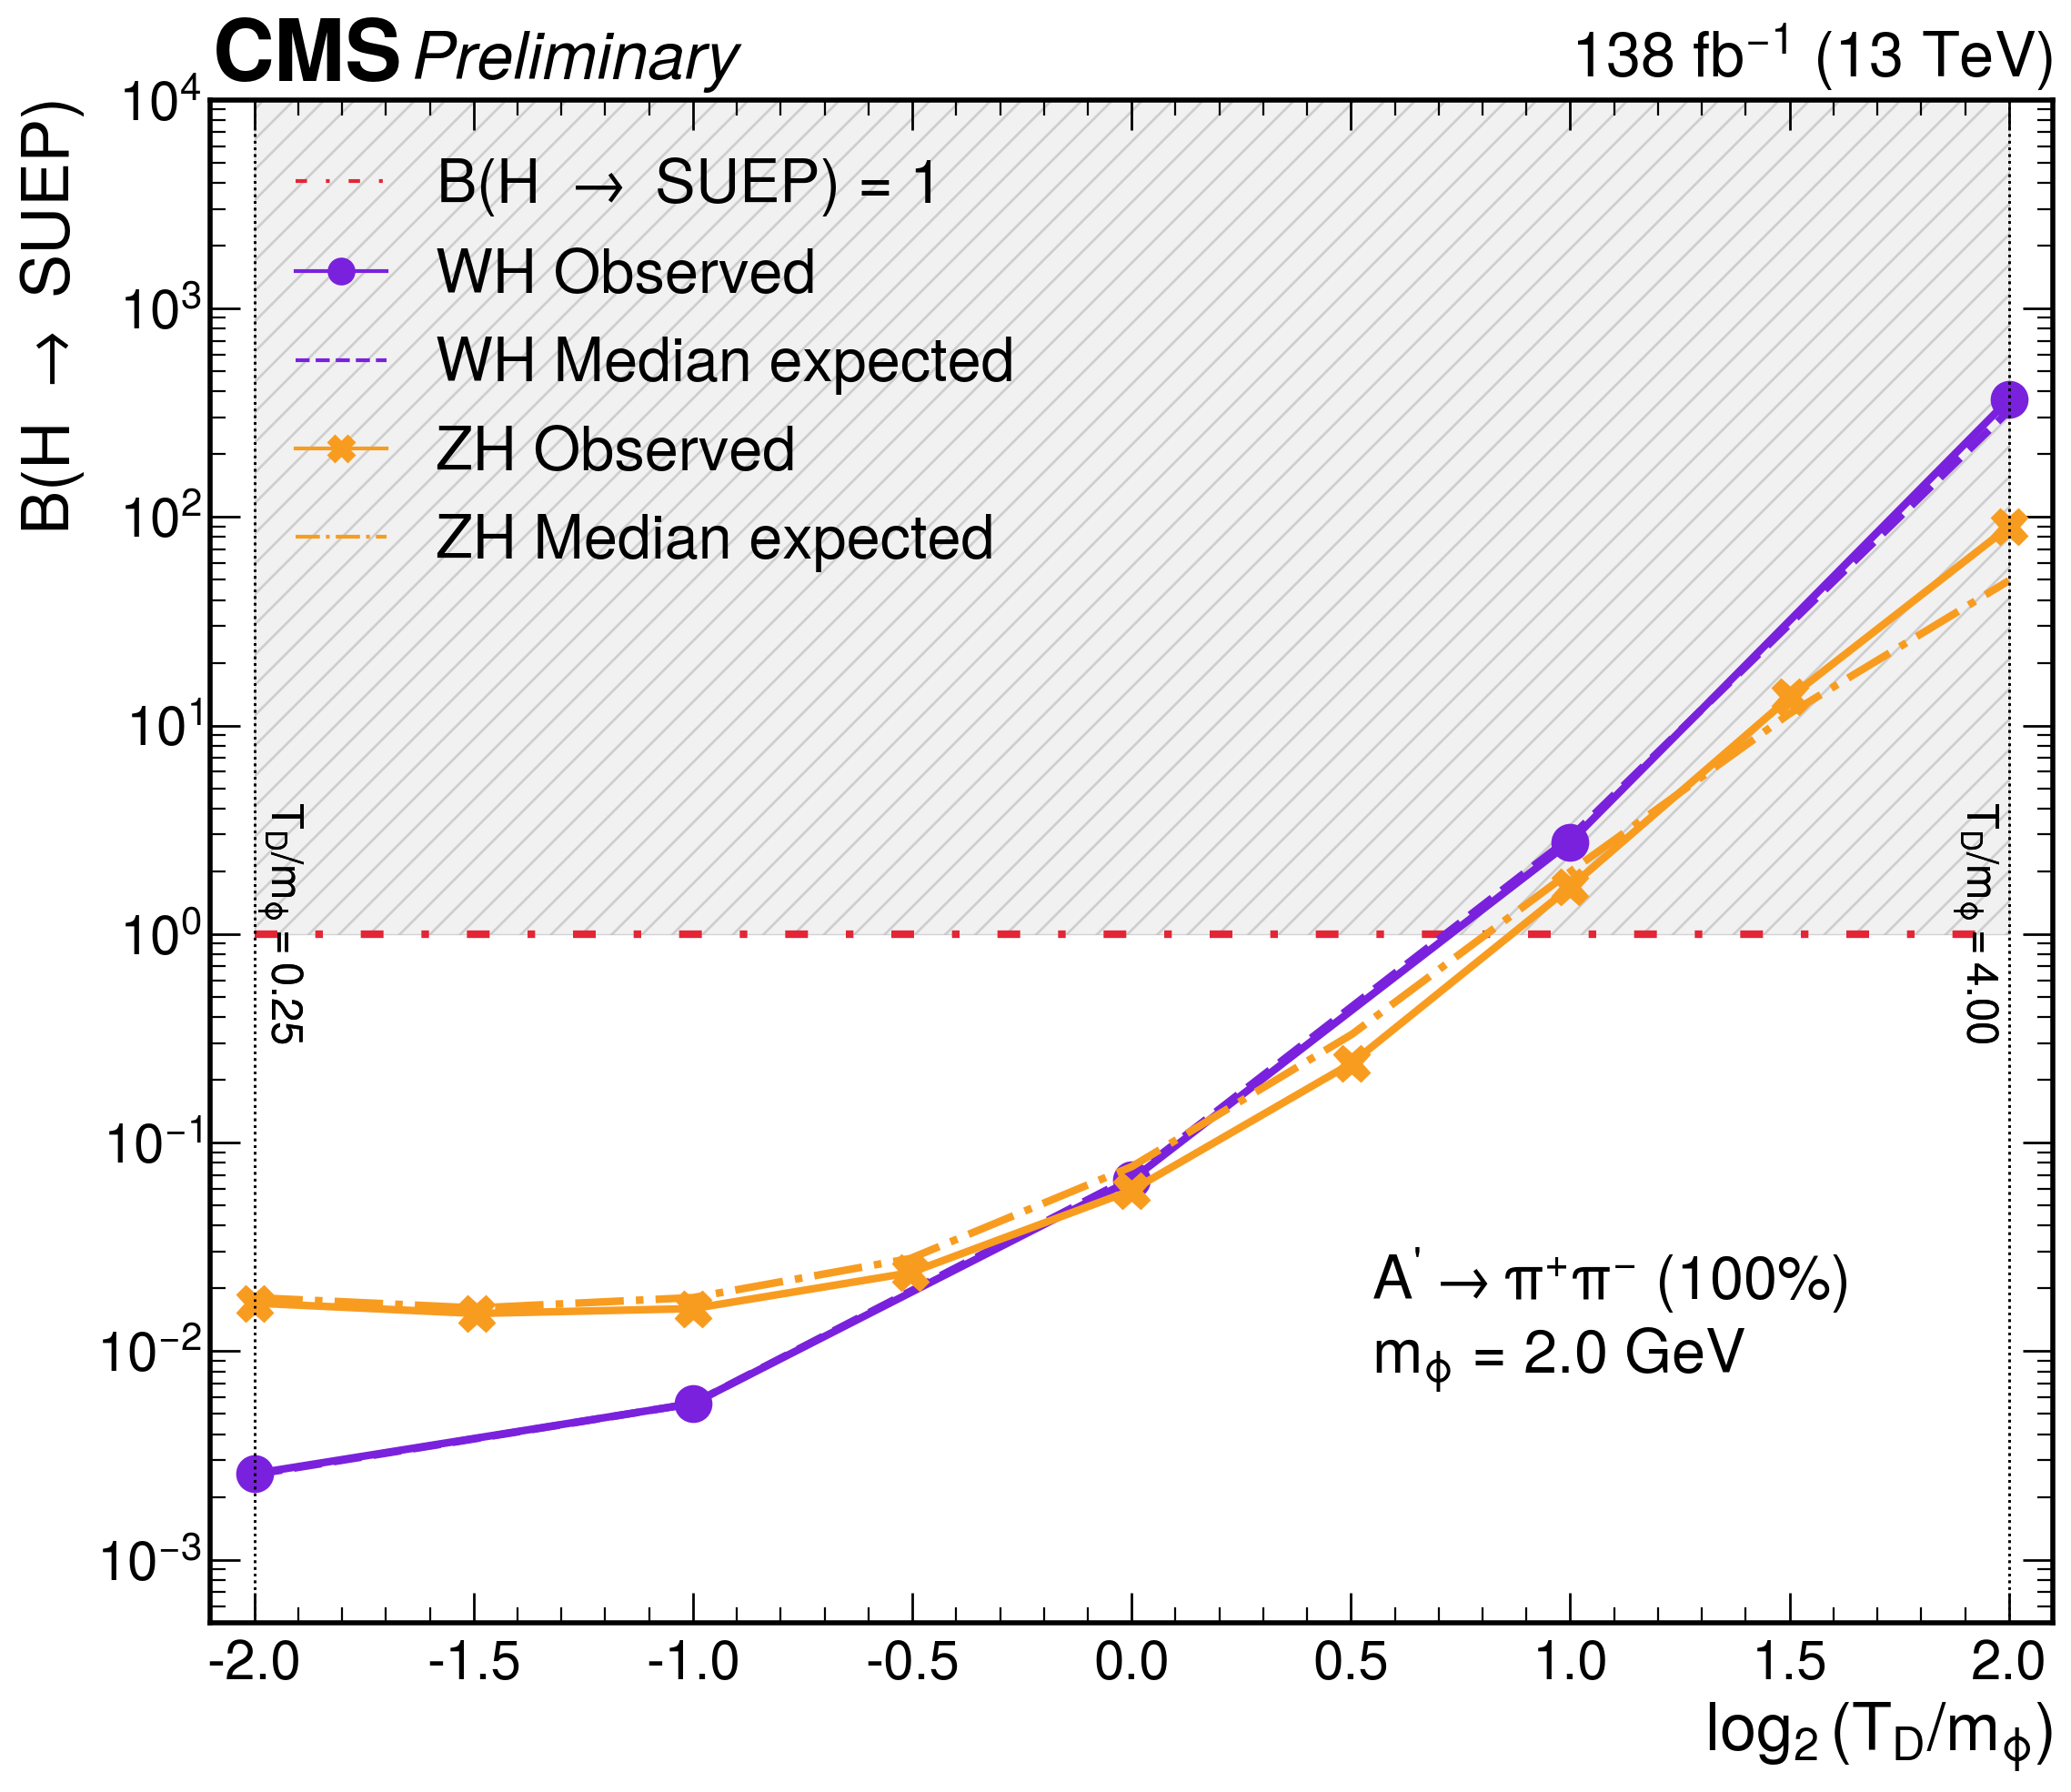

In [7]:
mphis = [
    2.000,
    #3.000,
    # 4.000,
    # 8.000
]

for mphi in mphis:

    fig = utils.plot_limits_log2T_by_mD(
        mD=mphi, ms=125, decay='generic',
        path='../cards/WH_3_9/', method='AsymptoticLimits', analysis='wh',
        obs_marker='o', exp_linestyle='--', bands_cmap='cms', mu_limit=True, bands=False,
        legend_label = 'WH ',
        color='#7a21dd'
    )
    ax = utils.plot_limits_log2T_by_mD(
        mD=mphi, ms=125, decay='generic',
        path='/ceph/submit/data/user/l/lavezzo/SUEP/outputs/ZHlimits/',
        method='AsymptoticLimits',
        analysis='zh', mu_limit=True,
        ax=fig.axes[0],
        exp_alpha=0.8,
        exp_linestyle="-.",
        obs_marker='X',
        color="#f89c20",
        bands=False,
        bands_cmap='yellow_green',
        legend_label = 'ZH '
    )

    hep.cms.label(data=True, llabel='Preliminary', lumi=utils.lumis['combined'], ax=fig.get_axes()[0])

    # ax.set_ylim(top=1e7)
    ax.set_ylim(5e-4, 1e4)

    # ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=20))
    # ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation())

    # # Set minor ticks explicitly to appear (2-9 between each power of 10)
    # ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=10))

    # # Suppress minor tick labels
    # ax.yaxis.set_minor_formatter(ticker.NullFormatter())

    #fig.set_size_inches(12, 10, forward=True)

    # Add a rectangle to cover the top-right space
    rect = plt.Rectangle((-2, 1), width=4, height=ax.get_ylim()[1], 
                        transform=ax.transData, facecolor='lightgray', edgecolor='gray', alpha=0.3, linewidth=0.5, zorder=0, hatch='//')
    rect.set_rasterized(True)
    ax.add_patch(rect)

    _ = ax.text(
            0.63, 0.15, utils.decaysLabelsWithLineBreaks['generic']+"\n$m_{{\phi}}$ = {} GeV".format(mphi),
            fontsize=24, horizontalalignment='left', 
            verticalalignment='bottom', 
            transform=ax.transAxes,
    )

    handles, labels = fig.get_axes()[0].get_legend_handles_labels()
    fig.get_axes()[0].legend(handles, labels, loc=(0.03, 0.67), fontsize=24, ncol=1)

    # if saveToPAS:
    #     fig.savefig(outDirPAS + "WZ_limits_log2TovermPhi_mPhi_{}".format(int(mphi)) + '.pdf', bbox_inches='tight', dpi=300)

    fig.savefig(outDir + "WZ_limits_log2TovermPhi_mPhi_{}".format(int(mphi)) + '.png', bbox_inches='tight', dpi=300)

    plt.show()